In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload CSV file
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("Nassau Candy Distributor.csv")

print("Dataset loaded successfully!")

Saving Nassau Candy Distributor.csv to Nassau Candy Distributor.csv
Dataset loaded successfully!


In [2]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 10194
Number of Columns: 18


In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [5]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [6]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
df = df.drop_duplicates()

In [9]:
print("Zero Sales:", (df["Sales"] == 0).sum())
print("Negative Sales:", (df["Sales"] < 0).sum())

Zero Sales: 0
Negative Sales: 0


In [10]:
print("Zero Units:", (df["Units"] == 0).sum())
print("Negative Units:", (df["Units"] < 0).sum())

Zero Units: 0
Negative Units: 0


In [11]:
print("Negative Gross Profit:",
      (df["Gross Profit"] < 0).sum())

print("Zero Gross Profit:",
      (df["Gross Profit"] == 0).sum())

Negative Gross Profit: 0
Zero Gross Profit: 0


In [12]:
df["Calculated Profit"] = df["Sales"] - df["Cost"]

difference = (
    df["Calculated Profit"] - df["Gross Profit"]
).abs()

print("Incorrect Gross Profit Records:",
      (difference > 0.000001).sum())

Incorrect Gross Profit Records: 0


In [13]:
df.drop(columns=["Calculated Profit"], inplace=True)

In [14]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [15]:
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [16]:
print("First Order Date:", df["Order Date"].min())
print("Last Order Date:", df["Order Date"].max())

First Order Date: 2024-01-02 00:00:00
Last Order Date: 2025-12-31 00:00:00


In [17]:
print(df["Division"].value_counts())

Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64


In [18]:
print("Unique Products:",
      df["Product Name"].nunique())

Unique Products: 15


In [19]:
print(df["Region"].value_counts())

Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64


In [20]:
print(df["Ship Mode"].value_counts())

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64


In [21]:
print("Unique Customers:",
      df["Customer ID"].nunique())

Unique Customers: 5044


In [22]:
# Gross Margin %
df["Gross Margin %"] = (
    df["Gross Profit"] / df["Sales"]
) * 100

# Profit per Unit
df["Profit per Unit"] = (
    df["Gross Profit"] / df["Units"]
)

# Revenue Contribution %
df["Revenue Contribution %"] = (
    df["Sales"] / df["Sales"].sum()
) * 100

# Profit Contribution %
df["Profit Contribution %"] = (
    df["Gross Profit"] / df["Gross Profit"].sum()
) * 100

In [23]:
df[
    [
        "Product Name",
        "Sales",
        "Cost",
        "Gross Profit",
        "Gross Margin %",
        "Profit per Unit"
    ]
].head()

,Product Name,Sales,Cost,Gross Profit,Gross Margin %,Profit per Unit
0,Wonka Bar - Milk Chocolate,6.50,2.28,4.22,64.923077,2.11
1,Wonka Bar - Triple Dazzle Caramel,7.50,2.60,4.90,65.333333,2.45
2,Wonka Bar - Nutty Crunch Surprise,10.47,3.00,7.47,71.346705,2.49
3,Wonka Bar -Scrumdiddlyumptious,10.80,3.30,7.50,69.444444,2.50
4,Wonka Bar - Triple Dazzle Caramel,11.25,3.90,7.35,65.333333,2.45


In [24]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [25]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:",
      df.duplicated().sum())

Final Dataset Shape: (10194, 26)

Missing Values:
Row ID                    0
Order ID                  0
Order Date                0
Ship Date                 0
Ship Mode                 0
Customer ID               0
Country/Region            0
City                      0
State/Province            0
Postal Code               0
Division                  0
Region                    0
Product ID                0
Product Name              0
Sales                     0
Units                     0
Gross Profit              0
Cost                      0
Gross Margin %            0
Profit per Unit           0
Revenue Contribution %    0
Profit Contribution %     0
Year                      0
Month                     0
Month Name                0
Year-Month                0
dtype: int64

Duplicate Rows: 0


In [26]:
# OVERALL BUSINESS PERFORMANCE

total_sales = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Gross Profit"].sum()
total_units = df["Units"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

overall_margin = (total_profit / total_sales) * 100

print("========== OVERALL BUSINESS PERFORMANCE ==========")

print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Cost        : ${total_cost:,.2f}")
print(f"Total Gross Profit: ${total_profit:,.2f}")
print(f"Total Units Sold  : {total_units:,}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Gross Margin      : {overall_margin:.2f}%")

========== OVERALL BUSINESS PERFORMANCE ==========
Total Sales       : $141,783.63
Total Cost        : $48,340.83
Total Gross Profit: $93,442.80
Total Units Sold  : 38,654
Total Orders      : 8,549
Total Customers   : 5,044
Gross Margin      : 65.91%


In [27]:
# PRODUCT PERFORMANCE ANALYSIS
product_analysis = (
        df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

product_analysis["Gross Margin %"] = (
    product_analysis["Gross_Profit"] /
    product_analysis["Sales"]
) * 100

product_analysis["Profit per Unit"] = (
    product_analysis["Gross_Profit"] /
    product_analysis["Units"]
)

product_analysis = product_analysis.sort_values(
    "Gross_Profit",
    ascending=False
)

product_analysis

,Product Name,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %,Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,1704,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,1677,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,1768,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,6755,1529,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,1527,66.666667,2.40
6,Lickable Wallpaper,7860.00,3930.00,3930.00,393,92,50.000000,10.00
14,Wonka Gum,597.50,286.80,310.70,478,118,52.000000,0.65
0,Everlasting Gobstopper,130.00,26.00,104.00,13,3,80.000000,8.00
4,Kazookles,1205.75,1113.00,92.75,371,94,7.692308,0.25
3,Hair Toffee,76.50,17.00,59.50,17,4,77.777778,3.50


In [28]:
# TOP 10 PRODUCTS BY PROFIT

top_10_profit = product_analysis.head(10)

print("TOP 10 PRODUCTS BY GROSS PROFIT")
display(top_10_profit)

TOP 10 PRODUCTS BY GROSS PROFIT


,Product Name,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %,Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,1704,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,1677,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,1768,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,6755,1529,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,1527,66.666667,2.40
6,Lickable Wallpaper,7860.00,3930.00,3930.00,393,92,50.000000,10.00
14,Wonka Gum,597.50,286.80,310.70,478,118,52.000000,0.65
0,Everlasting Gobstopper,130.00,26.00,104.00,13,3,80.000000,8.00
4,Kazookles,1205.75,1113.00,92.75,371,94,7.692308,0.25
3,Hair Toffee,76.50,17.00,59.50,17,4,77.777778,3.50


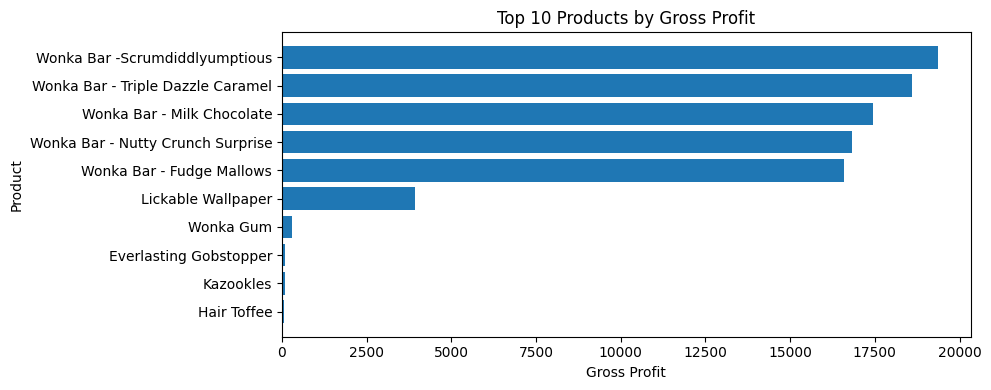

In [29]:
# PRODUCT PROFIT VISUALIZATION

plt.figure(figsize=(10, 4))

plt.barh(
    top_10_profit["Product Name"],
    top_10_profit["Gross_Profit"]
)

plt.xlabel("Gross Profit")
plt.ylabel("Product")
plt.title("Top 10 Products by Gross Profit")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

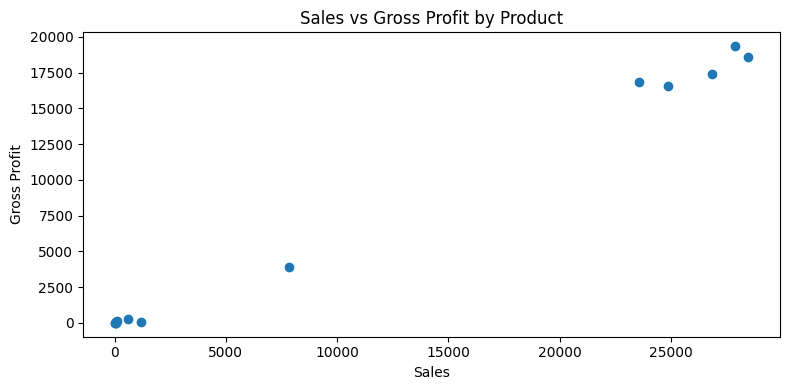

In [30]:
# SALES VS PROFIT BY PRODUCT

plt.figure(figsize=(8, 4))

plt.scatter(
    product_analysis["Sales"],
    product_analysis["Gross_Profit"]
)

plt.xlabel("Sales")
plt.ylabel("Gross Profit")
plt.title("Sales vs Gross Profit by Product")

plt.tight_layout()
plt.show()

In [31]:
#REGION PERFORMANCE ANALYSIS

region_analysis = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

region_analysis["Gross Margin %"] = (
    region_analysis["Gross_Profit"] /
    region_analysis["Sales"]
) * 100

region_analysis["Profit per Unit"] = (
    region_analysis["Gross_Profit"] /
    region_analysis["Units"]
)

region_analysis = region_analysis.sort_values(
    "Gross_Profit",
    ascending=False
)

display(region_analysis)

,Region,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %,Profit per Unit
3,Pacific,46301.53,15815.59,30485.94,12466,2744,65.842187,2.445527
0,Atlantic,41197.24,14223.54,26973.70,11159,2476,65.474532,2.417215
2,Interior,32037.60,10755.11,21282.49,8820,1979,66.429726,2.412981
1,Gulf,22247.26,7546.59,14700.67,6209,1350,66.078564,2.367639


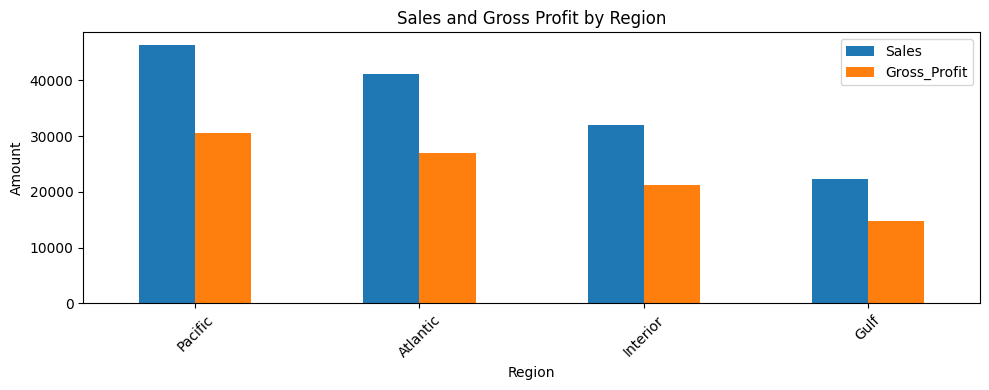

In [32]:
# REGION SALES & PROFIT

region_analysis.plot(
    x="Region",
    y=["Sales", "Gross_Profit"],
    kind="bar",
    figsize=(10, 4)
)

plt.title("Sales and Gross Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
#DIVISION PERFORMANCE ANALYSIS
division_analysis = (
    df.groupby("Division")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

division_analysis["Gross Margin %"] = (
    division_analysis["Gross_Profit"] /
    division_analysis["Sales"]
) * 100

division_analysis["Profit per Unit"] = (
    division_analysis["Gross_Profit"] /
    division_analysis["Units"]
)

division_analysis = division_analysis.sort_values(
    "Gross_Profit",
    ascending=False
)

display(division_analysis)

,Division,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %,Profit per Unit
0,Chocolate,131692.90,42868.28,88824.62,37275,8205,67.448298,2.382954
1,Other,9663.25,5329.80,4333.45,1242,304,44.844643,3.489090
2,Sugar,427.48,142.75,284.73,137,40,66.606625,2.078321


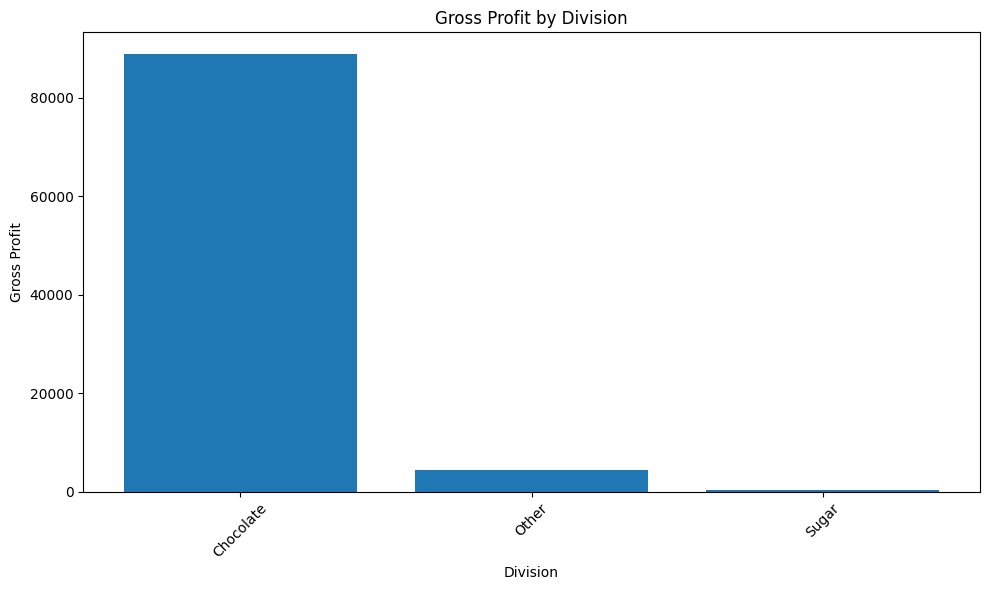

In [34]:
# DIVISION PROFITABILITY

plt.figure(figsize=(10,6))

plt.bar(
    division_analysis["Division"],
    division_analysis["Gross_Profit"]
)

plt.title("Gross Profit by Division")
plt.xlabel("Division")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

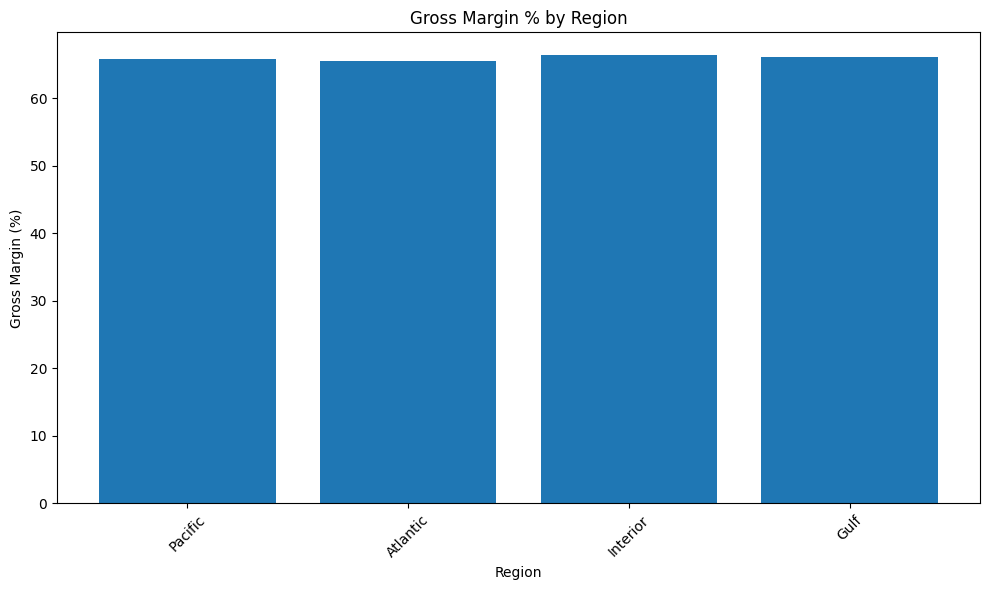

In [35]:
#GROSS MARGIN BY REGION

plt.figure(figsize=(10, 6))

plt.bar(
    region_analysis["Region"],
    region_analysis["Gross Margin %"]
)

plt.title("Gross Margin % by Region")
plt.xlabel("Region")
plt.ylabel("Gross Margin (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
# TIME-BASED SALES & PROFIT ANALYSIS
# Make sure Order Date is in datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create Year and Month
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

# Monthly analysis
monthly_analysis = (
    df.groupby(["Year", "Month"])
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

# Calculate Gross Margin
monthly_analysis["Gross Margin %"] = (
    monthly_analysis["Gross_Profit"] /
    monthly_analysis["Sales"]
) * 100

# Create Year-Month column
monthly_analysis["Year-Month"] = (
    monthly_analysis["Year"].astype(str)
    + "-"
    + monthly_analysis["Month"].astype(str).str.zfill(2)
)

display(monthly_analysis)

,Year,Month,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %,Year-Month
0,2024,1,2093.90,727.76,1366.14,566,115,65.243803,2024-01
1,2024,2,1379.87,471.28,908.59,398,97,65.846058,2024-02
2,2024,3,4138.90,1467.74,2671.16,1125,255,64.537921,2024-03
3,2024,4,3988.22,1375.41,2612.81,1079,239,65.513186,2024-04
4,2024,5,3951.52,1336.08,2615.44,1099,245,66.188201,2024-05
5,2024,6,3518.76,1188.04,2330.72,1010,227,66.236970,2024-06
6,2024,7,3865.38,1300.12,2565.26,1107,223,66.365015,2024-07
7,2024,8,4477.65,1531.78,2945.87,1227,260,65.790537,2024-08
8,2024,9,7912.10,2705.40,5206.70,2105,479,65.806802,2024-09
9,2024,10,4815.98,1696.52,3119.46,1237,275,64.773110,2024-10


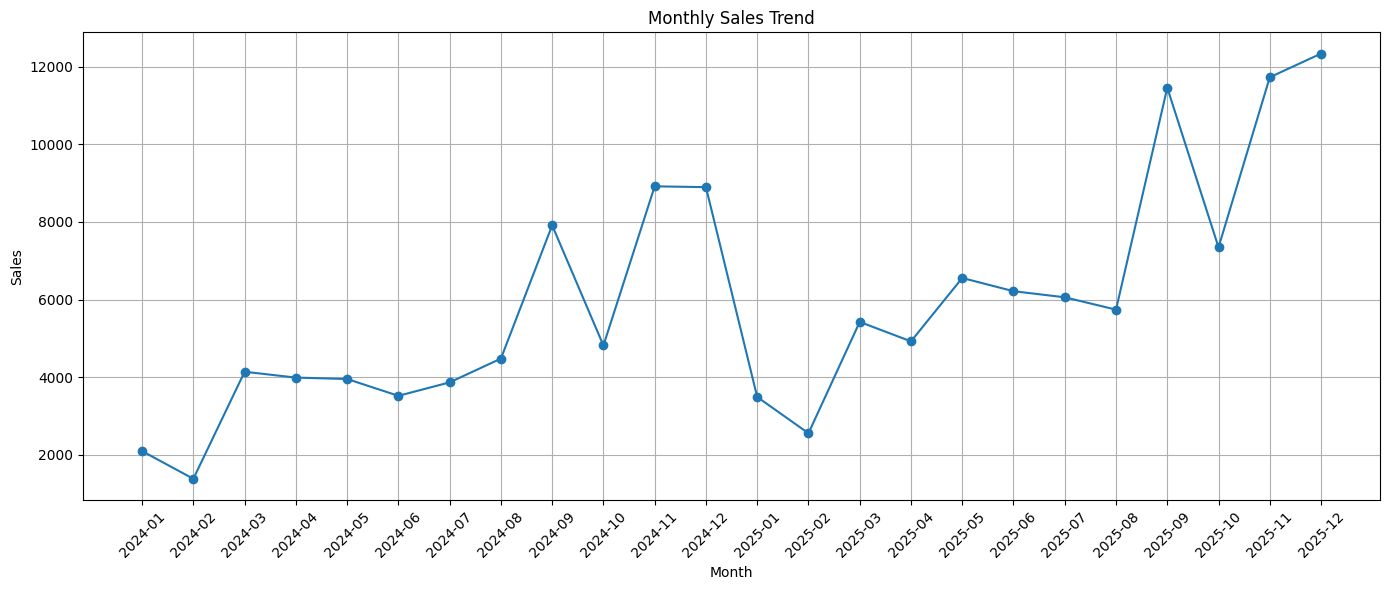

In [37]:
# MONTHLY SALES TREND

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["Year-Month"],
    monthly_analysis["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

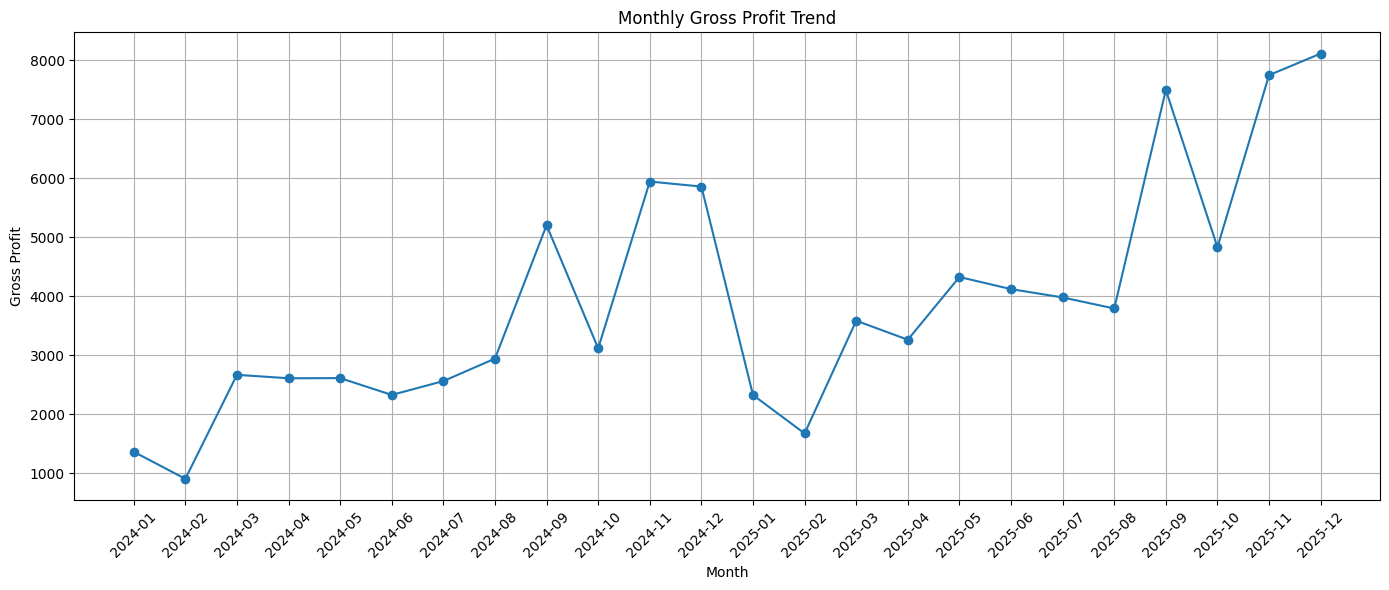

In [38]:
# MONTHLY GROSS PROFIT TREND
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["Year-Month"],
    monthly_analysis["Gross_Profit"],
    marker="o"
)

plt.title("Monthly Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Gross Profit")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

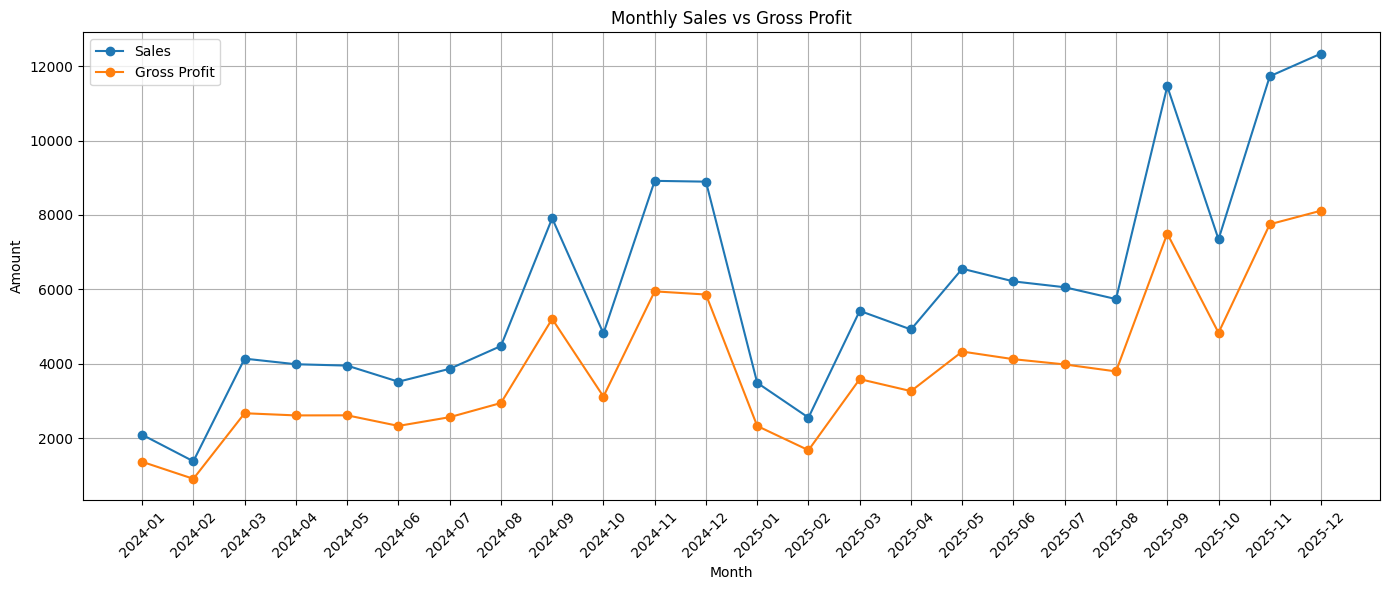

In [39]:
# SALES VS GROSS PROFIT TREND
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["Year-Month"],
    monthly_analysis["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_analysis["Year-Month"],
    monthly_analysis["Gross_Profit"],
    marker="o",
    label="Gross Profit"
)

plt.title("Monthly Sales vs Gross Profit")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [40]:
# STEP 40: YEARLY PERFORMANCE ANALYSIS
yearly_analysis = (
    df.groupby("Year")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

yearly_analysis["Gross Margin %"] = (
    yearly_analysis["Gross_Profit"] /
    yearly_analysis["Sales"]
) * 100

display(yearly_analysis)

,Year,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %
0,2024,57956.20,19804.77,38151.43,15899,3482,65.828039
1,2025,83827.43,28536.06,55291.37,22755,5067,65.958565


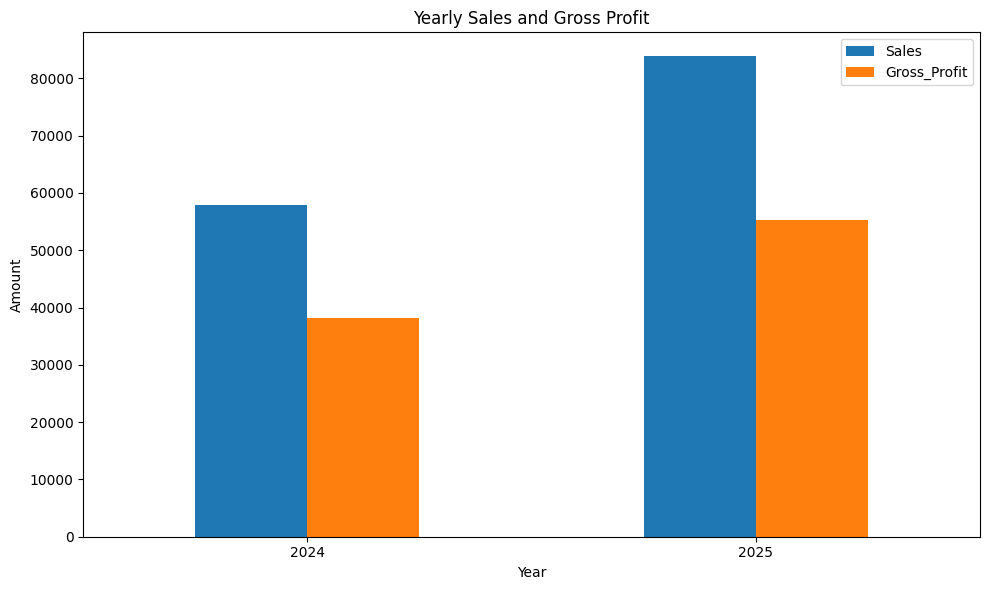

In [41]:
#YEARLY SALES & PROFIT
yearly_analysis.plot(
    x="Year",
    y=["Sales", "Gross_Profit"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Yearly Sales and Gross Profit")
plt.xlabel("Year")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
#PRODUCT LINE PROFITABILITY ANALYSIS

product_line_analysis = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

# Gross Margin %
product_line_analysis["Gross Margin %"] = (
    product_line_analysis["Gross_Profit"] /
    product_line_analysis["Sales"]
) * 100

# Profit per Unit
product_line_analysis["Profit per Unit"] = (
    product_line_analysis["Gross_Profit"] /
    product_line_analysis["Units"]
)

# Sort by Gross Profit
product_line_analysis = product_line_analysis.sort_values(
    "Gross_Profit",
    ascending=False
)

display(product_line_analysis)

,Product Name,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %,Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,1704,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,1677,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,1768,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,6755,1529,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,1527,66.666667,2.40
6,Lickable Wallpaper,7860.00,3930.00,3930.00,393,92,50.000000,10.00
14,Wonka Gum,597.50,286.80,310.70,478,118,52.000000,0.65
0,Everlasting Gobstopper,130.00,26.00,104.00,13,3,80.000000,8.00
4,Kazookles,1205.75,1113.00,92.75,371,94,7.692308,0.25
3,Hair Toffee,76.50,17.00,59.50,17,4,77.777778,3.50


In [43]:
# FORMAT PRODUCT LINE RESULTS

product_line_display = product_line_analysis.copy()

product_line_display["Sales"] = (
    product_line_display["Sales"].map("${:,.2f}".format)
)

product_line_display["Cost"] = (
    product_line_display["Cost"].map("${:,.2f}".format)
)

product_line_display["Gross_Profit"] = (
    product_line_display["Gross_Profit"].map("${:,.2f}".format)
)

product_line_display["Gross Margin %"] = (
    product_line_display["Gross Margin %"].map("{:.2f}%".format)
)

product_line_display["Profit per Unit"] = (
    product_line_display["Profit per Unit"].map("${:,.2f}".format)
)

display(product_line_display)

,Product Name,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %,Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,"$27,874.80","$8,517.30","$19,357.50",7743,1704,69.44%,$2.50
12,Wonka Bar - Triple Dazzle Caramel,"$28,485.00","$9,874.80","$18,610.20",7596,1677,65.33%,$2.45
10,Wonka Bar - Milk Chocolate,"$26,867.75","$9,424.38","$17,443.37",8267,1768,64.92%,$2.11
11,Wonka Bar - Nutty Crunch Surprise,"$23,574.95","$6,755.00","$16,819.95",6755,1529,71.35%,$2.49
9,Wonka Bar - Fudge Mallows,"$24,890.40","$8,296.80","$16,593.60",6914,1527,66.67%,$2.40
6,Lickable Wallpaper,"$7,860.00","$3,930.00","$3,930.00",393,92,50.00%,$10.00
14,Wonka Gum,$597.50,$286.80,$310.70,478,118,52.00%,$0.65
0,Everlasting Gobstopper,$130.00,$26.00,$104.00,13,3,80.00%,$8.00
4,Kazookles,"$1,205.75","$1,113.00",$92.75,371,94,7.69%,$0.25
3,Hair Toffee,$76.50,$17.00,$59.50,17,4,77.78%,$3.50


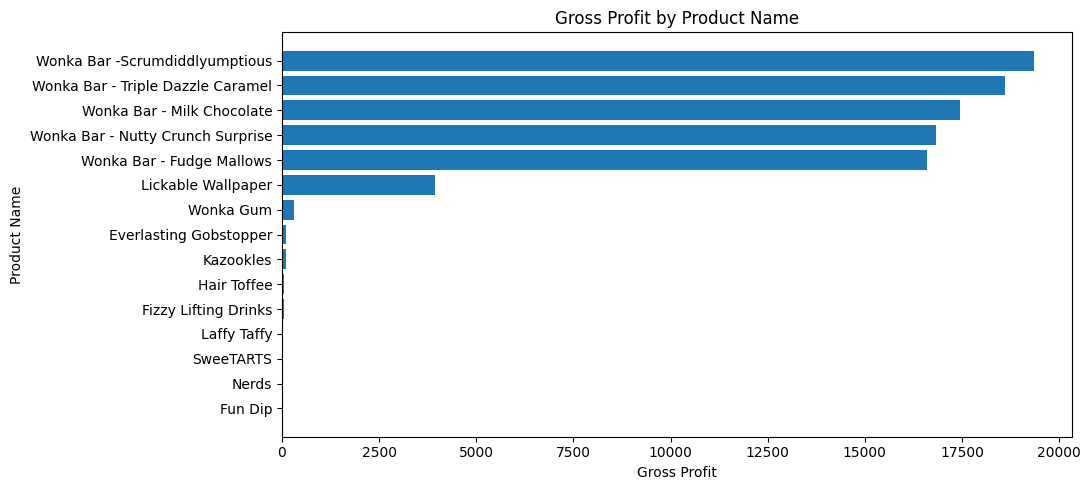

In [44]:
#GROSS PROFIT BY PRODUCT LINE

plt.figure(figsize=(11, 5))

plt.barh(
    product_line_analysis["Product Name"],
    product_line_analysis["Gross_Profit"]
)

plt.title("Gross Profit by Product Name")
plt.xlabel("Gross Profit")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

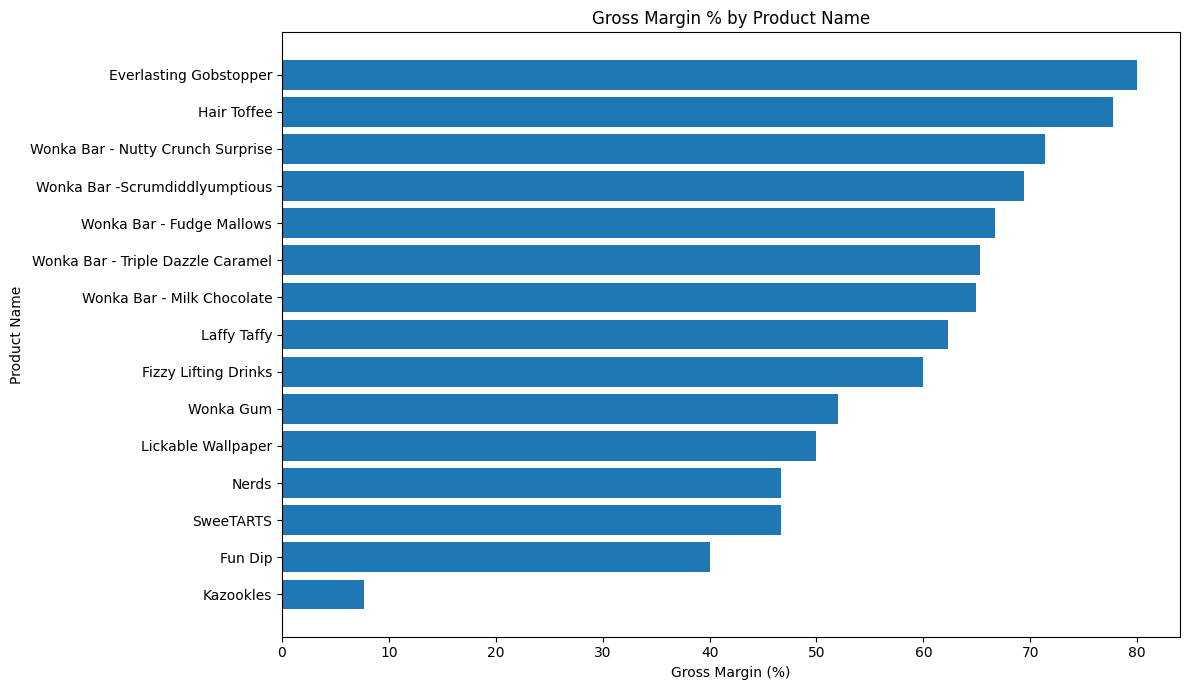

In [45]:
#GROSS MARGIN % BY PRODUCT LINE

margin_sorted = product_line_analysis.sort_values(
    "Gross Margin %",
    ascending=False
)

plt.figure(figsize=(12, 7))

plt.barh(
    margin_sorted["Product Name"],
    margin_sorted["Gross Margin %"]
)

plt.title("Gross Margin % by Product Name")
plt.xlabel("Gross Margin (%)")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

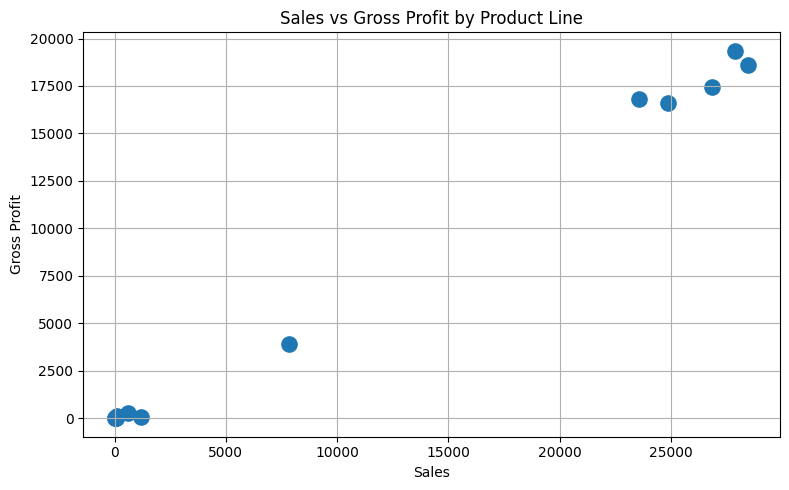

In [46]:
# SALES VS GROSS PROFIT

plt.figure(figsize=(8, 5))

plt.scatter(
    product_line_analysis["Sales"],
    product_line_analysis["Gross_Profit"],
    s=120
)

plt.xlabel("Sales")
plt.ylabel("Gross Profit")
plt.title("Sales vs Gross Profit by Product Line")

plt.grid(True)

plt.tight_layout()
plt.show()

In [47]:
# PROFIT CONTRIBUTION

total_gross_profit = product_line_analysis["Gross_Profit"].sum()

product_line_analysis["Profit Contribution %"] = (
    product_line_analysis["Gross_Profit"] /
    total_gross_profit
) * 100

profit_contribution = product_line_analysis.sort_values(
    "Profit Contribution %",
    ascending=False
)

display(
    profit_contribution[
        [
            "Product Name",
            "Gross_Profit",
            "Profit Contribution %"
        ]
    ]
)

,Product Name,Gross_Profit,Profit Contribution %
13,Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882
12,Wonka Bar - Triple Dazzle Caramel,18610.20,19.916141
10,Wonka Bar - Milk Chocolate,17443.37,18.667431
11,Wonka Bar - Nutty Crunch Surprise,16819.95,18.000263
9,Wonka Bar - Fudge Mallows,16593.60,17.758030
6,Lickable Wallpaper,3930.00,4.205782
14,Wonka Gum,310.70,0.332503
0,Everlasting Gobstopper,104.00,0.111298
4,Kazookles,92.75,0.099259
3,Hair Toffee,59.50,0.063675


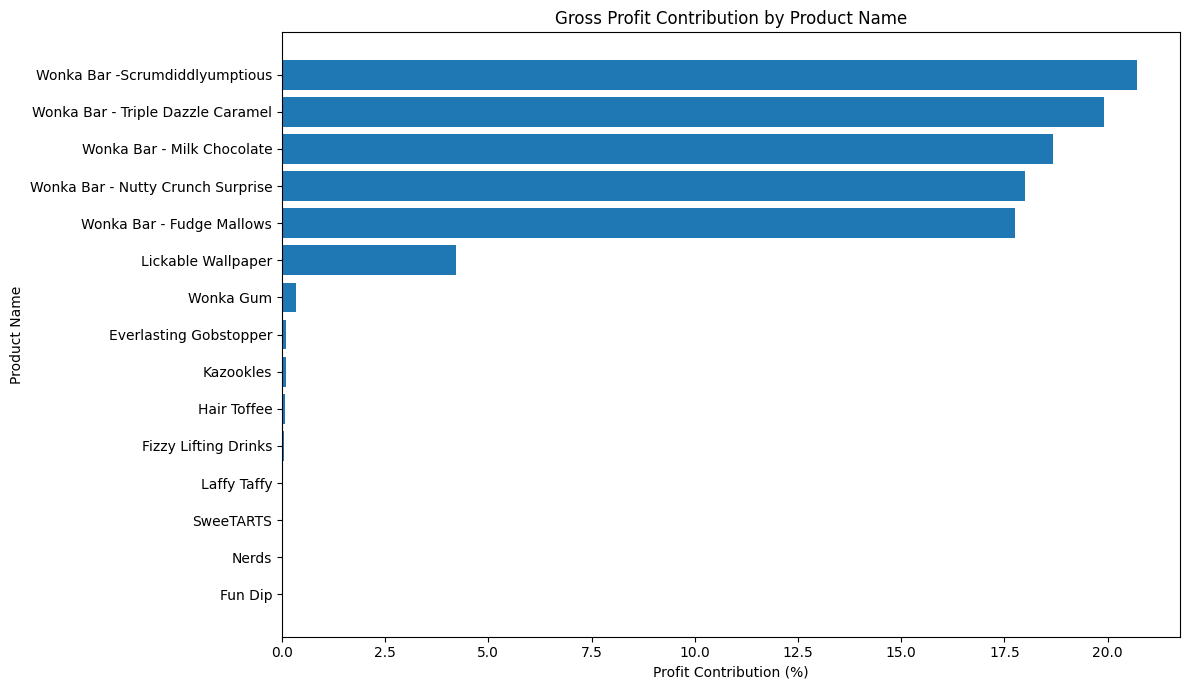

In [48]:
# PROFIT CONTRIBUTION CHART

plt.figure(figsize=(12, 7))

plt.barh(
    profit_contribution["Product Name"],
    profit_contribution["Profit Contribution %"]
)

plt.title("Gross Profit Contribution by Product Name")
plt.xlabel("Profit Contribution (%)")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [49]:
# HIGHEST & LOWEST MARGIN
highest_margin = product_line_analysis.loc[
    product_line_analysis["Gross Margin %"].idxmax()
]

lowest_margin = product_line_analysis.loc[
    product_line_analysis["Gross Margin %"].idxmin()
]

print("========== HIGHEST MARGIN PRODUCT NAME ==========")
print(f"Product Name: {highest_margin['Product Name']}")
print(f"Gross Margin : {highest_margin['Gross Margin %']:.2f}%")
print(f"Gross Profit : ${highest_margin['Gross_Profit']:,.2f}")

print("\n========== LOWEST MARGIN PRODUCT NAME ==========")
print(f"Product Name : {lowest_margin['Product Name']}")
print(f"Gross Margin : {lowest_margin['Gross Margin %']:.2f}%")
print(f"Gross Profit : ${lowest_margin['Gross_Profit']:,.2f}")

========== HIGHEST MARGIN PRODUCT NAME ==========
Product Name: Everlasting Gobstopper
Gross Margin : 80.00%
Gross Profit : $104.00

========== LOWEST MARGIN PRODUCT NAME ==========
Product Name : Kazookles
Gross Margin : 7.69%
Gross Profit : $92.75


In [50]:
#FINAL PROFITABILITY TABLE

final_profitability = product_line_analysis[
    [
        "Product Name",
        "Sales",
        "Cost",
        "Gross_Profit",
        "Gross Margin %",
        "Profit per Unit",
        "Units",
        "Orders",
        "Profit Contribution %"
    ]
].sort_values(
    "Gross_Profit",
    ascending=False
)

display(final_profitability)

,Product Name,Sales,Cost,Gross_Profit,Gross Margin %,Profit per Unit,Units,Orders,Profit Contribution %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,69.444444,2.50,7743,1704,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,65.333333,2.45,7596,1677,19.916141
10,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,64.923077,2.11,8267,1768,18.667431
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,71.346705,2.49,6755,1529,18.000263
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,66.666667,2.40,6914,1527,17.758030
6,Lickable Wallpaper,7860.00,3930.00,3930.00,50.000000,10.00,393,92,4.205782
14,Wonka Gum,597.50,286.80,310.70,52.000000,0.65,478,118,0.332503
0,Everlasting Gobstopper,130.00,26.00,104.00,80.000000,8.00,13,3,0.111298
4,Kazookles,1205.75,1113.00,92.75,7.692308,0.25,371,94,0.099259
3,Hair Toffee,76.50,17.00,59.50,77.777778,3.50,17,4,0.063675


In [51]:
#TOP 10 PRODUCT LINES BY PROFIT

top_10_product_lines = (
    product_line_analysis
    .sort_values("Gross_Profit", ascending=False)
    .head(10)
)

display(
    top_10_product_lines[
        [
            "Product Name",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Profit per Unit",
            "Units"
        ]
    ]
)

,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit,Units
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,2.50,7743
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,2.45,7596
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,2.11,8267
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,2.49,6755
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,2.40,6914
6,Lickable Wallpaper,7860.00,3930.00,50.000000,10.00,393
14,Wonka Gum,597.50,310.70,52.000000,0.65,478
0,Everlasting Gobstopper,130.00,104.00,80.000000,8.00,13
4,Kazookles,1205.75,92.75,7.692308,0.25,371
3,Hair Toffee,76.50,59.50,77.777778,3.50,17


In [52]:
#BOTTOM 10 PRODUCT LINES BY PROFIT

bottom_10_product_lines = (
    product_line_analysis
    .sort_values("Gross_Profit", ascending=True)
    .head(10)
)

display(
    bottom_10_product_lines[
        [
            "Product Name",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Profit per Unit",
            "Units"
        ]
    ]
)

,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit,Units
2,Fun Dip,12.00,4.80,40.000000,0.60,8
7,Nerds,15.00,7.00,46.666667,0.70,10
8,SweeTARTS,61.50,28.70,46.666667,0.70,41
5,Laffy Taffy,53.73,33.48,62.311558,1.24,27
1,Fizzy Lifting Drinks,78.75,47.25,60.000000,2.25,21
3,Hair Toffee,76.50,59.50,77.777778,3.50,17
4,Kazookles,1205.75,92.75,7.692308,0.25,371
0,Everlasting Gobstopper,130.00,104.00,80.000000,8.00,13
14,Wonka Gum,597.50,310.70,52.000000,0.65,478
6,Lickable Wallpaper,7860.00,3930.00,50.000000,10.00,393


In [53]:
#TOP 10 BY GROSS MARGIN

top_10_margin = (
    product_line_analysis
    .sort_values("Gross Margin %", ascending=False)
    .head(10)
)

display(
    top_10_margin[
        [
            "Product Name",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Profit per Unit"
        ]
    ]
)

,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit
0,Everlasting Gobstopper,130.00,104.00,80.000000,8.00
3,Hair Toffee,76.50,59.50,77.777778,3.50
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,2.49
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,2.50
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,2.40
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,2.11
5,Laffy Taffy,53.73,33.48,62.311558,1.24
1,Fizzy Lifting Drinks,78.75,47.25,60.000000,2.25
14,Wonka Gum,597.50,310.70,52.000000,0.65


In [54]:
#BOTTOM 10 BY GROSS MARGIN

bottom_10_margin = (
    product_line_analysis
    .sort_values("Gross Margin %", ascending=True)
    .head(10)
)

display(
    bottom_10_margin[
        [
            "Product Name",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Profit per Unit"
        ]
    ]
)

,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit
4,Kazookles,1205.75,92.75,7.692308,0.25
2,Fun Dip,12.00,4.80,40.000000,0.60
7,Nerds,15.00,7.00,46.666667,0.70
8,SweeTARTS,61.50,28.70,46.666667,0.70
6,Lickable Wallpaper,7860.00,3930.00,50.000000,10.00
14,Wonka Gum,597.50,310.70,52.000000,0.65
1,Fizzy Lifting Drinks,78.75,47.25,60.000000,2.25
5,Laffy Taffy,53.73,33.48,62.311558,1.24
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,2.11
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,2.45


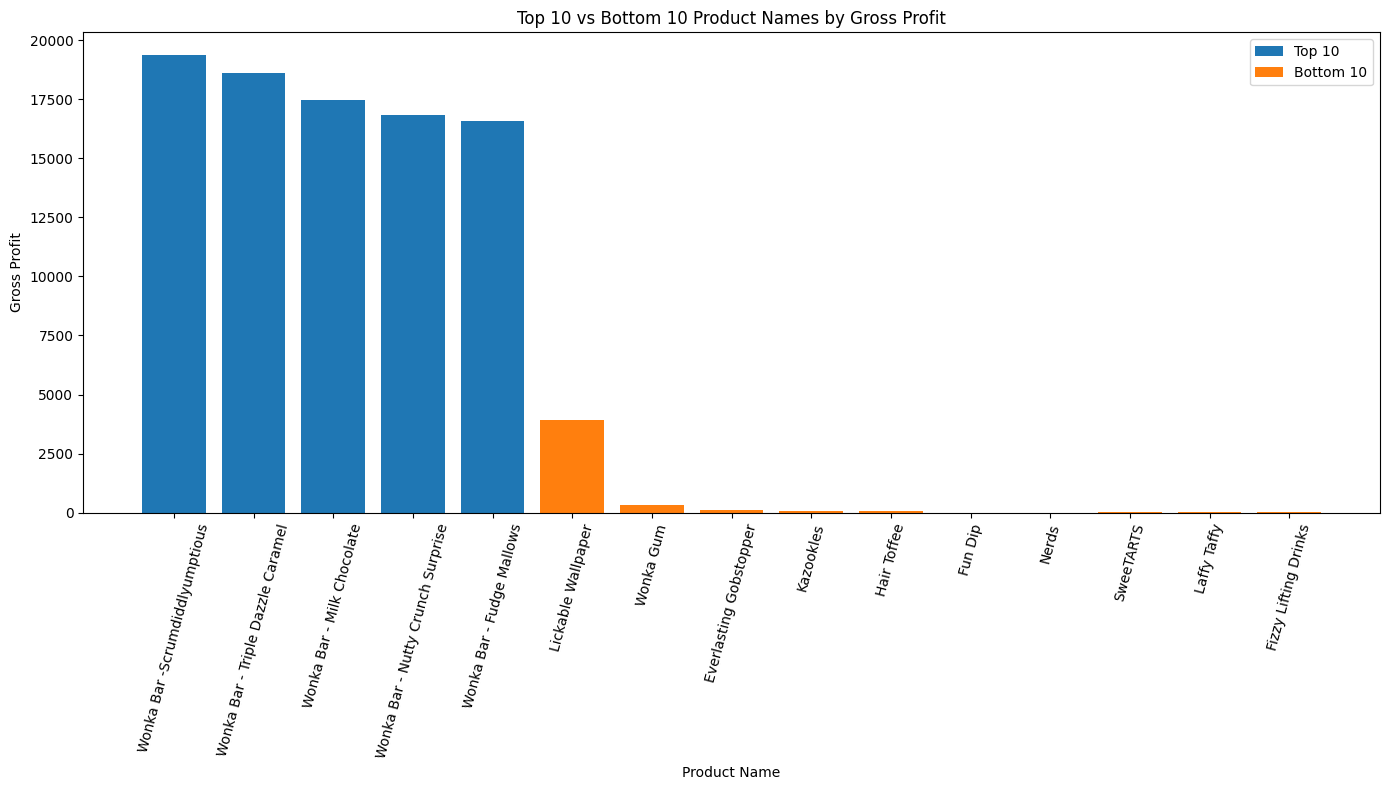

In [55]:
#TOP VS BOTTOM PROFIT

comparison = pd.concat([
    top_10_product_lines.assign(Group="Top 10"),
    bottom_10_product_lines.assign(Group="Bottom 10")
])

plt.figure(figsize=(14, 8))

for group in comparison["Group"].unique():
    data = comparison[comparison["Group"] == group]

    plt.bar(
        data["Product Name"],
        data["Gross_Profit"],
        label=group
    )

plt.title("Top 10 vs Bottom 10 Product Names by Gross Profit")
plt.xlabel("Product Name")
plt.ylabel("Gross Profit")
plt.xticks(rotation=75)
plt.legend()

plt.tight_layout()
plt.show()

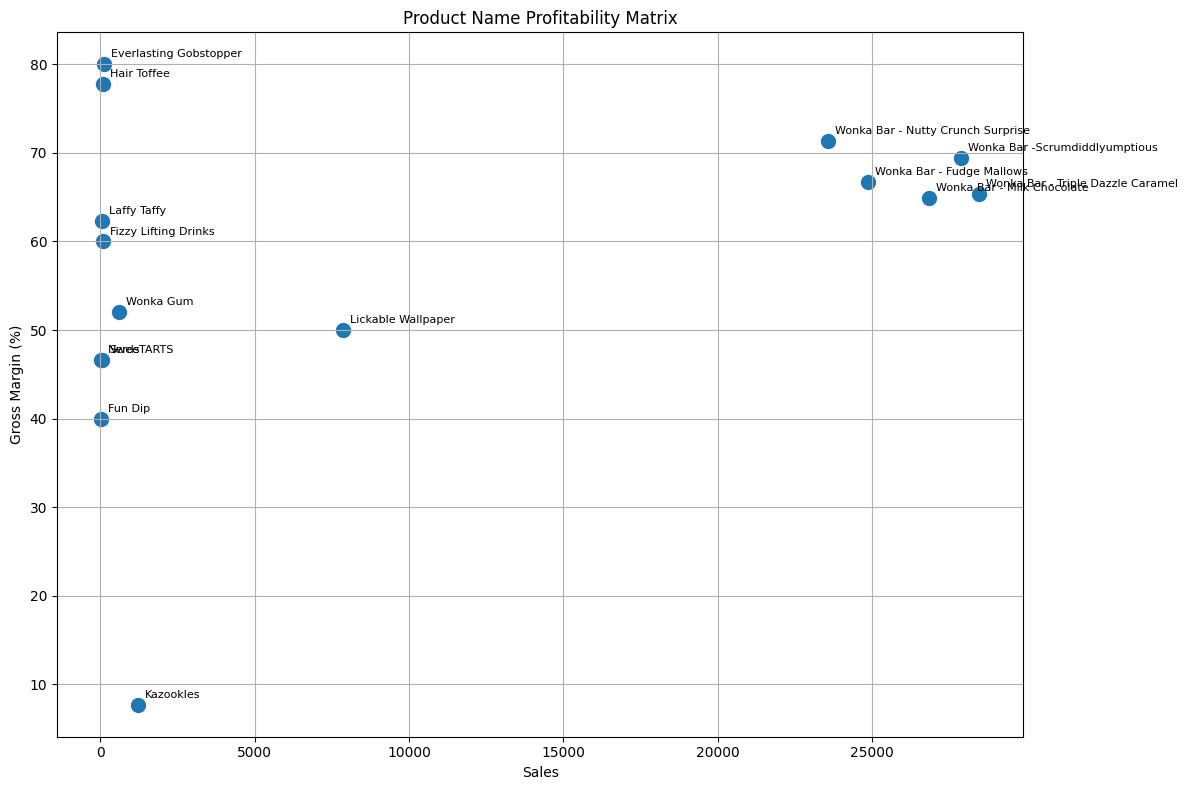

In [56]:
#PROFITABILITY MATRIX

plt.figure(figsize=(12, 8))

plt.scatter(
    product_line_analysis["Sales"],
    product_line_analysis["Gross Margin %"],
    s=100
)

for _, row in product_line_analysis.iterrows():
    plt.annotate(
        row["Product Name"],
        (row["Sales"], row["Gross Margin %"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Sales")
plt.ylabel("Gross Margin (%)")
plt.title("Product Name Profitability Matrix")
plt.grid(True)

plt.tight_layout()
plt.show()

In [57]:
# FOUR-GROUP PROFITABILITY ANALYSIS

sales_median = product_line_analysis["Sales"].median()
margin_median = product_line_analysis["Gross Margin %"].median()

product_line_matrix = product_line_analysis.copy()

product_line_matrix["Performance Group"] = np.where(
    (product_line_matrix["Sales"] >= sales_median) &
    (product_line_matrix["Gross Margin %"] >= margin_median),
    "High Sales - High Margin",
    np.where(
        (product_line_matrix["Sales"] >= sales_median) &
        (product_line_matrix["Gross Margin %"] < margin_median),
        "High Sales - Low Margin",
        np.where(
            (product_line_matrix["Sales"] < sales_median) &
            (product_line_matrix["Gross Margin %"] >= margin_median),
            "Low Sales - High Margin",
            "Low Sales - Low Margin"
        )
    )
)

display(
    product_line_matrix[
        [
            "Product Name",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Profit per Unit",
            "Performance Group"
        ]
    ].sort_values(
        ["Performance Group", "Gross_Profit"],
        ascending=[True, False]
    )
)

,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit,Performance Group
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,2.50,High Sales - High Margin
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,2.45,High Sales - High Margin
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,2.11,High Sales - High Margin
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,2.49,High Sales - High Margin
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,2.40,High Sales - High Margin
6,Lickable Wallpaper,7860.00,3930.00,50.000000,10.00,High Sales - Low Margin
14,Wonka Gum,597.50,310.70,52.000000,0.65,High Sales - Low Margin
4,Kazookles,1205.75,92.75,7.692308,0.25,High Sales - Low Margin
0,Everlasting Gobstopper,130.00,104.00,80.000000,8.00,Low Sales - High Margin
3,Hair Toffee,76.50,59.50,77.777778,3.50,Low Sales - High Margin


In [58]:
#PERFORMANCE GROUP SUMMARY

group_summary = (
    product_line_matrix["Performance Group"]
    .value_counts()
    .reset_index()
)

group_summary.columns = [
    "Performance Group",
    "Number of Product Lines"
]

display(group_summary)

,Performance Group,Number of Product Lines
0,High Sales - High Margin,5
1,Low Sales - Low Margin,4
2,High Sales - Low Margin,3
3,Low Sales - High Margin,3


In [59]:
#SAVE PRODUCT LINE ANALYSIS

product_line_matrix.to_csv(
    "Product_Name_Profitability_Analysis.csv",
    index=False
)

print("Product Name Profitability Analysis saved successfully.")

Product Name Profitability Analysis saved successfully.


In [60]:
# ADVANCED PROFITABILITY ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Create a fresh product-level summary
advanced_product_analysis = (
    df.groupby(["Product ID", "Product Name"], as_index=False)
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum"),
          Orders=("Order ID", "nunique")
      )
)

# Calculate profitability metrics
advanced_product_analysis["Gross Margin %"] = (
    advanced_product_analysis["Gross_Profit"]
    / advanced_product_analysis["Sales"] * 100
)

advanced_product_analysis["Profit per Unit"] = (
    advanced_product_analysis["Gross_Profit"]
    / advanced_product_analysis["Units"]
)

advanced_product_analysis["Revenue Contribution %"] = (
    advanced_product_analysis["Sales"]
    / advanced_product_analysis["Sales"].sum() * 100
)

advanced_product_analysis["Profit Contribution %"] = (
    advanced_product_analysis["Gross_Profit"]
    / advanced_product_analysis["Gross_Profit"].sum() * 100
)

# Rank products
advanced_product_analysis["Profit Rank"] = (
    advanced_product_analysis["Gross_Profit"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

advanced_product_analysis["Margin Rank"] = (
    advanced_product_analysis["Gross Margin %"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Sort by gross profit
advanced_product_analysis = advanced_product_analysis.sort_values(
    "Gross_Profit", ascending=False
).reset_index(drop=True)

print("Advanced product profitability analysis completed.")
display(advanced_product_analysis.round(2))

Advanced product profitability analysis completed.


,Product ID,Product Name,Sales,Cost,Gross_Profit,Units,Orders,Gross Margin %,Profit per Unit,Revenue Contribution %,Profit Contribution %,Profit Rank,Margin Rank
0,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,1704,69.44,2.50,19.66,20.72,1,4
1,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,1677,65.33,2.45,20.09,19.92,2,6
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,1768,64.92,2.11,18.95,18.67,3,7
3,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,6755,1529,71.35,2.49,16.63,18.00,4,3
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,1527,66.67,2.40,17.56,17.76,5,5
5,OTH-LIC-15000,Lickable Wallpaper,7860.00,3930.00,3930.00,393,92,50.00,10.00,5.54,4.21,6,11
6,OTH-GUM-21000,Wonka Gum,597.50,286.80,310.70,478,118,52.00,0.65,0.42,0.33,7,10
7,SUG-EVE-47000,Everlasting Gobstopper,130.00,26.00,104.00,13,3,80.00,8.00,0.09,0.11,8,1
8,OTH-KAZ-38000,Kazookles,1205.75,1113.00,92.75,371,94,7.69,0.25,0.85,0.10,9,14
9,SUG-HAI-55000,Hair Toffee,76.50,17.00,59.50,17,4,77.78,3.50,0.05,0.06,10,2


In [61]:
# TOP AND BOTTOM PRODUCT ANALYSIS

print("========== TOP 5 PRODUCTS BY GROSS PROFIT ==========")

display(
    advanced_product_analysis[
        [
            "Product Name",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Profit per Unit"
        ]
    ].head(5).round(2)
)

print("========== BOTTOM 5 PRODUCTS BY GROSS PROFIT ==========")

display(
    advanced_product_analysis[
        [
            "Product Name",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Profit per Unit"
        ]
    ].tail(5).round(2)
)

print("========== TOP 5 PRODUCTS BY GROSS MARGIN ==========")

display(
    advanced_product_analysis.sort_values(
        "Gross Margin %", ascending=False
    )[
        [
            "Product Name",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Profit per Unit"
        ]
    ].head(5).round(2)
)

========== TOP 5 PRODUCTS BY GROSS PROFIT ==========


,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit
0,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,2.50
1,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33,2.45
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92,2.11
3,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35,2.49
4,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67,2.40


========== BOTTOM 5 PRODUCTS BY GROSS PROFIT ==========


,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit
10,Fizzy Lifting Drinks,78.75,47.25,60.00,2.25
11,Laffy Taffy,53.73,33.48,62.31,1.24
12,SweeTARTS,61.50,28.70,46.67,0.70
13,Nerds,15.00,7.00,46.67,0.70
14,Fun Dip,12.00,4.80,40.00,0.60


========== TOP 5 PRODUCTS BY GROSS MARGIN ==========


,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit
7,Everlasting Gobstopper,130.00,104.00,80.00,8.00
9,Hair Toffee,76.50,59.50,77.78,3.50
3,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35,2.49
0,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,2.50
4,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67,2.40


,Product Name,Gross_Profit,Profit Contribution %,Cumulative Profit %
0,Wonka Bar -Scrumdiddlyumptious,19357.50,20.72,20.72
1,Wonka Bar - Triple Dazzle Caramel,18610.20,19.92,40.63
2,Wonka Bar - Milk Chocolate,17443.37,18.67,59.30
3,Wonka Bar - Nutty Crunch Surprise,16819.95,18.00,77.30
4,Wonka Bar - Fudge Mallows,16593.60,17.76,95.06
5,Lickable Wallpaper,3930.00,4.21,99.26
6,Wonka Gum,310.70,0.33,99.60
7,Everlasting Gobstopper,104.00,0.11,99.71
8,Kazookles,92.75,0.10,99.81
9,Hair Toffee,59.50,0.06,99.87


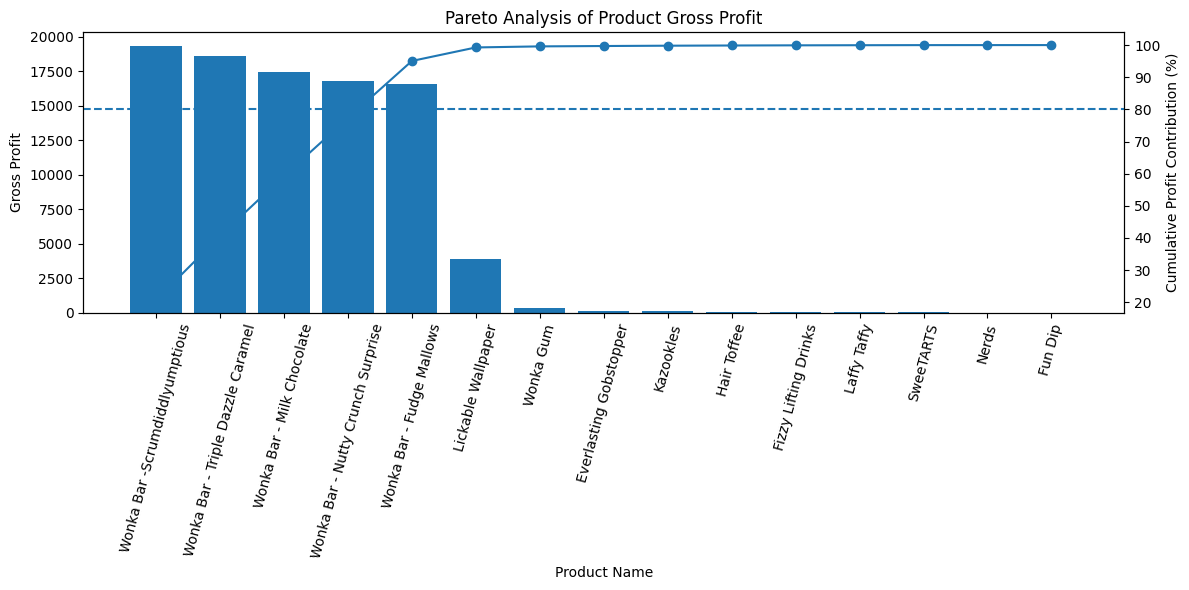

In [62]:
# STEP 61: PARETO PROFIT CONTRIBUTION ANALYSIS

pareto_analysis = advanced_product_analysis[
    ["Product Name", "Gross_Profit"]
].copy()

pareto_analysis = pareto_analysis.sort_values(
    "Gross_Profit", ascending=False
).reset_index(drop=True)

pareto_analysis["Profit Contribution %"] = (
    pareto_analysis["Gross_Profit"]
    / pareto_analysis["Gross_Profit"].sum() * 100
)

pareto_analysis["Cumulative Profit %"] = (
    pareto_analysis["Profit Contribution %"].cumsum()
)

display(pareto_analysis.round(2))

# Plot Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    pareto_analysis["Product Name"],
    pareto_analysis["Gross_Profit"]
)

ax1.set_xlabel("Product Name")
ax1.set_ylabel("Gross Profit")
ax1.tick_params(axis="x", rotation=75)

ax2 = ax1.twinx()

ax2.plot(
    pareto_analysis["Product Name"],
    pareto_analysis["Cumulative Profit %"],
    marker="o"
)

ax2.set_ylabel("Cumulative Profit Contribution (%)")
ax2.axhline(80, linestyle="--")

plt.title("Pareto Analysis of Product Gross Profit")
plt.tight_layout()
plt.show()

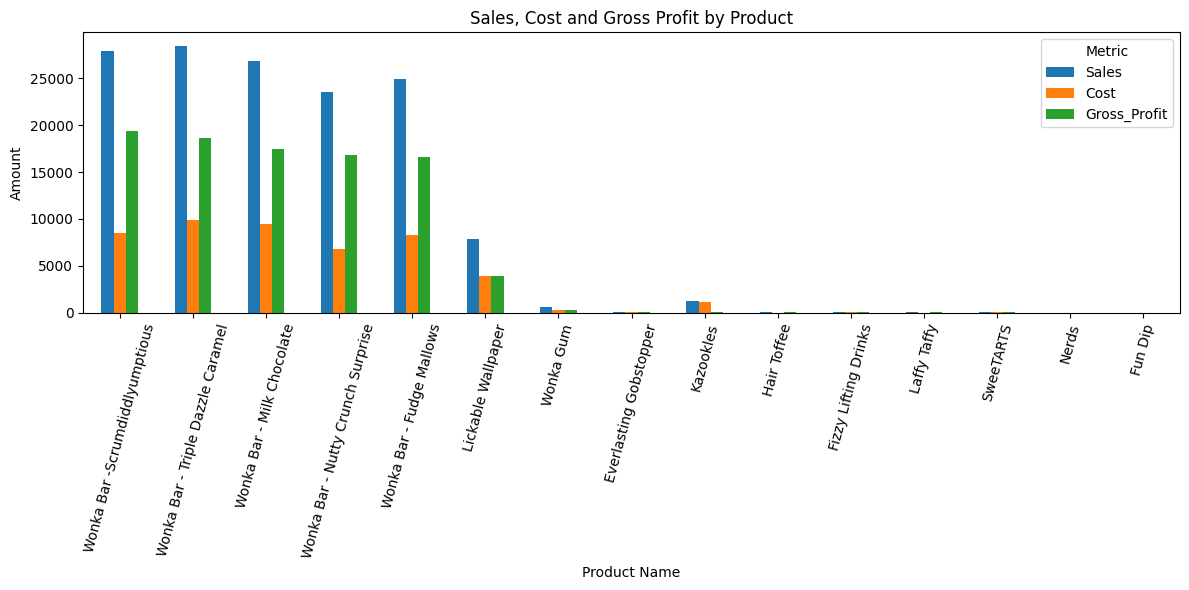

In [63]:
# SALES, COST AND PROFIT COMPARISON

comparison_data = advanced_product_analysis[
    ["Product Name", "Sales", "Cost", "Gross_Profit"]
].copy()

comparison_data = comparison_data.set_index("Product Name")

comparison_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sales, Cost and Gross Profit by Product")
plt.xlabel("Product Name")
plt.ylabel("Amount")
plt.xticks(rotation=75)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [64]:
#PRODUCT PROFITABILITY CLASSIFICATION

sales_median = advanced_product_analysis["Sales"].median()
margin_median = advanced_product_analysis["Gross Margin %"].median()

advanced_product_analysis["Profitability Category"] = np.select(
    [
        (
            (advanced_product_analysis["Sales"] >= sales_median) &
            (advanced_product_analysis["Gross Margin %"] >= margin_median)
        ),
        (
            (advanced_product_analysis["Sales"] >= sales_median) &
            (advanced_product_analysis["Gross Margin %"] < margin_median)
        ),
        (
            (advanced_product_analysis["Sales"] < sales_median) &
            (advanced_product_analysis["Gross Margin %"] >= margin_median)
        )
    ],
    [
        "High Sales - High Margin",
        "High Sales - Low Margin",
        "Low Sales - High Margin"
    ],
    default="Low Sales - Low Margin"
)

category_summary = (
    advanced_product_analysis["Profitability Category"]
    .value_counts()
    .reset_index()
)

category_summary.columns = [
    "Profitability Category",
    "Number of Products"
]

display(category_summary)

,Profitability Category,Number of Products
0,High Sales - High Margin,5
1,Low Sales - Low Margin,4
2,High Sales - Low Margin,3
3,Low Sales - High Margin,3


In [65]:
#OVERALL BUSINESS SUMMARY

total_sales = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Gross Profit"].sum()
total_units = df["Units"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

overall_margin = total_profit / total_sales * 100
profit_per_unit = total_profit / total_units

print("============================================")
print("       NASSAU CANDY DISTRIBUTOR SUMMARY")
print("============================================")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Cost: ${total_cost:,.2f}")
print(f"Total Gross Profit: ${total_profit:,.2f}")
print(f"Overall Gross Margin: {overall_margin:.2f}%")
print(f"Total Units Sold: {total_units:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Profit per Unit: ${profit_per_unit:,.2f}")

print("\nTop Product by Gross Profit:")
print(advanced_product_analysis.iloc[0]["Product Name"])

print("\nTop Product by Gross Margin:")
print(
    advanced_product_analysis.loc[
        advanced_product_analysis["Gross Margin %"].idxmax(),
        "Product Name"
    ]
)

       NASSAU CANDY DISTRIBUTOR SUMMARY
Total Sales: $141,783.63
Total Cost: $48,340.83
Total Gross Profit: $93,442.80
Overall Gross Margin: 65.91%
Total Units Sold: 38,654
Total Orders: 8,549
Total Customers: 5,044
Average Profit per Unit: $2.42

Top Product by Gross Profit:
Wonka Bar -Scrumdiddlyumptious

Top Product by Gross Margin:
Everlasting Gobstopper


In [66]:
#EXPORT FINAL ANALYSIS

advanced_product_analysis.to_csv(
    "Advanced_Product_Profitability_Analysis.csv",
    index=False
)

pareto_analysis.to_csv(
    "Product_Profit_Pareto_Analysis.csv",
    index=False
)

category_summary.to_csv(
    "Product_Profitability_Category_Summary.csv",
    index=False
)

print("All analysis files exported successfully.")

# Download the main output
from google.colab import files

files.download("Advanced_Product_Profitability_Analysis.csv")

All analysis files exported successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
# EXECUTIVE PROFITABILITY DASHBOARD

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# KPI calculations
total_sales = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Gross Profit"].sum()
total_units = df["Units"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

gross_margin = (total_profit / total_sales) * 100
profit_per_unit = total_profit / total_units

# Display KPIs

print("=" * 60)
print("        NASSAU CANDY DISTRIBUTOR")
print("        EXECUTIVE KPI DASHBOARD")
print("=" * 60)

print(f"\nTotal Sales          : ${total_sales:,.2f}")
print(f"Total Cost           : ${total_cost:,.2f}")
print(f"Gross Profit         : ${total_profit:,.2f}")
print(f"Gross Margin         : {gross_margin:.2f}%")
print(f"Units Sold           : {total_units:,}")
print(f"Orders               : {total_orders:,}")
print(f"Customers            : {total_customers:,}")
print(f"Profit per Unit      : ${profit_per_unit:.2f}")

print("=" * 60)

        NASSAU CANDY DISTRIBUTOR
        EXECUTIVE KPI DASHBOARD

Total Sales          : $141,783.63
Total Cost           : $48,340.83
Gross Profit         : $93,442.80
Gross Margin         : 65.91%
Units Sold           : 38,654
Orders               : 8,549
Customers            : 5,044
Profit per Unit      : $2.42


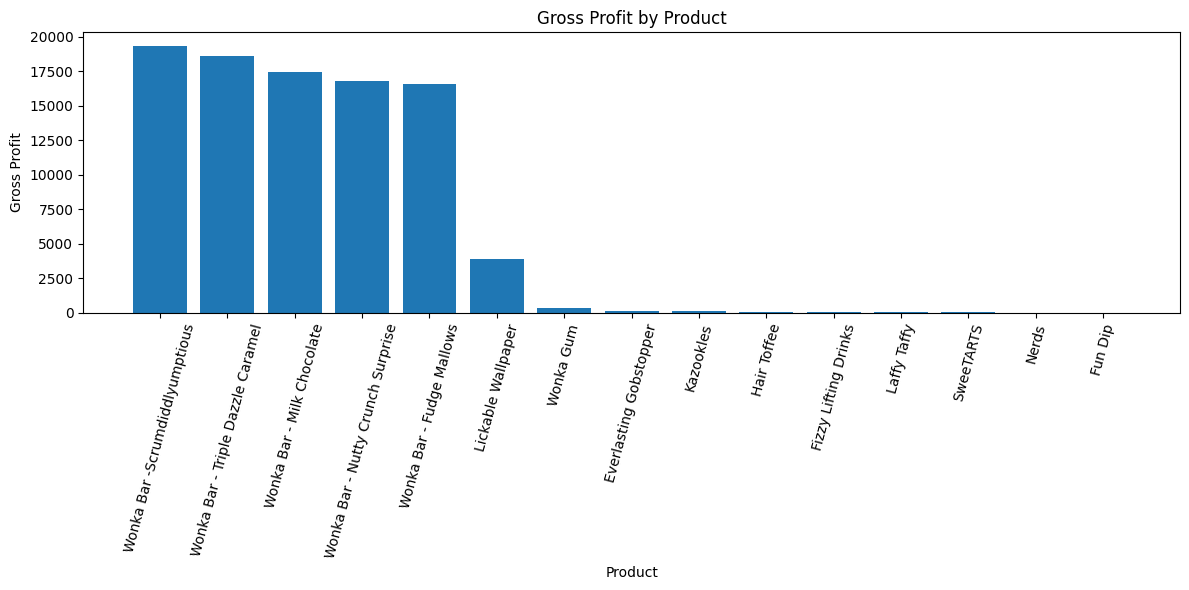

In [68]:
# PRODUCT PROFITABILITY DASHBOARD

product_dashboard = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

product_dashboard["Gross Margin %"] = (
    product_dashboard["Gross_Profit"]
    / product_dashboard["Sales"] * 100
)

product_dashboard = product_dashboard.sort_values(
    "Gross_Profit",
    ascending=False
)

# Gross Profit by Product


plt.figure(figsize=(12, 6))

plt.bar(
    product_dashboard["Product Name"],
    product_dashboard["Gross_Profit"]
)

plt.title("Gross Profit by Product")
plt.xlabel("Product")
plt.ylabel("Gross Profit")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

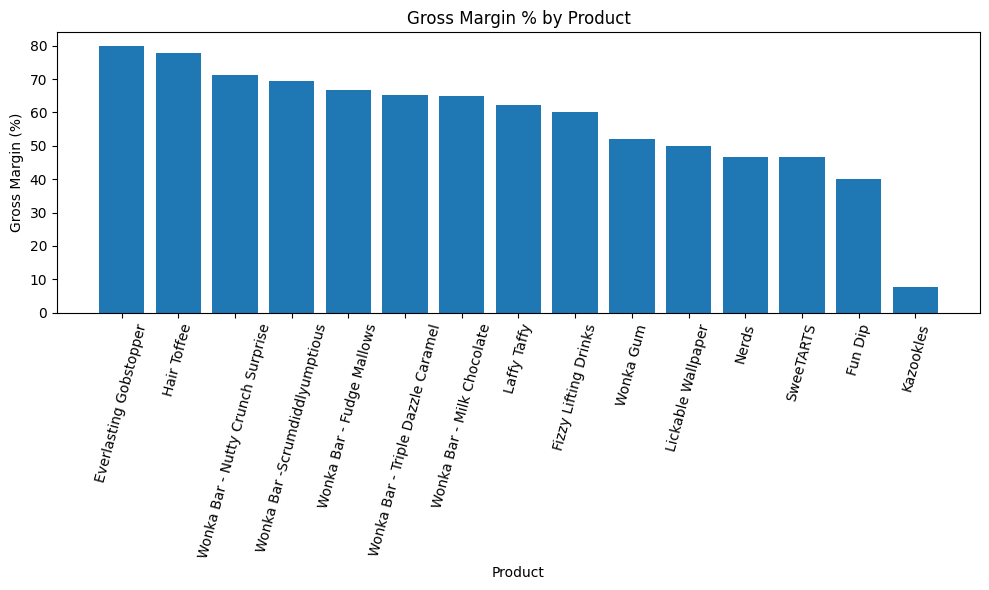

In [69]:
#GROSS MARGIN BY PRODUCT

margin_data = product_dashboard.sort_values(
    "Gross Margin %",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    margin_data["Product Name"],
    margin_data["Gross Margin %"]
)

plt.title("Gross Margin % by Product")
plt.xlabel("Product")
plt.ylabel("Gross Margin (%)")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

,Region,Sales,Cost,Gross_Profit,Units,Gross Margin %
0,Atlantic,41197.24,14223.54,26973.70,11159,65.47
1,Gulf,22247.26,7546.59,14700.67,6209,66.08
2,Interior,32037.60,10755.11,21282.49,8820,66.43
3,Pacific,46301.53,15815.59,30485.94,12466,65.84


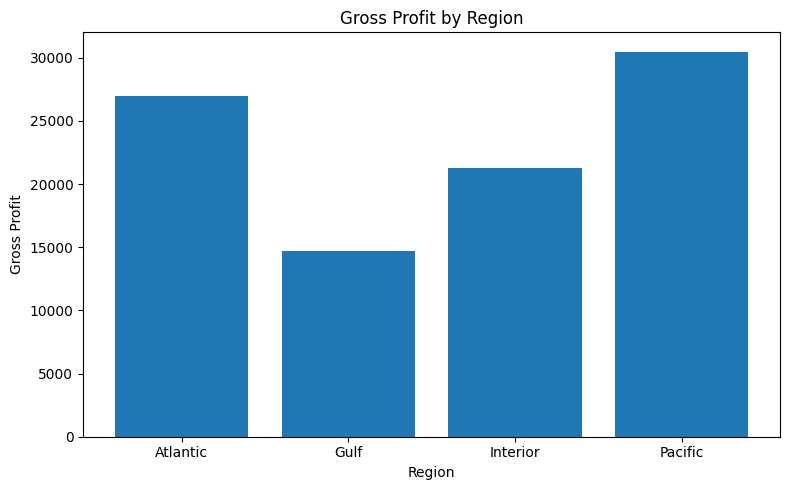

In [70]:
# REGIONAL PROFITABILITY
region_analysis = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

region_analysis["Gross Margin %"] = (
    region_analysis["Gross_Profit"]
    / region_analysis["Sales"] * 100
)

display(region_analysis.round(2))

plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Gross_Profit"]
)

plt.title("Gross Profit by Region")
plt.xlabel("Region")
plt.ylabel("Gross Profit")

plt.tight_layout()
plt.show()

,Division,Sales,Cost,Gross_Profit,Units,Gross Margin %
0,Chocolate,131692.90,42868.28,88824.62,37275,67.45
1,Other,9663.25,5329.80,4333.45,1242,44.84
2,Sugar,427.48,142.75,284.73,137,66.61


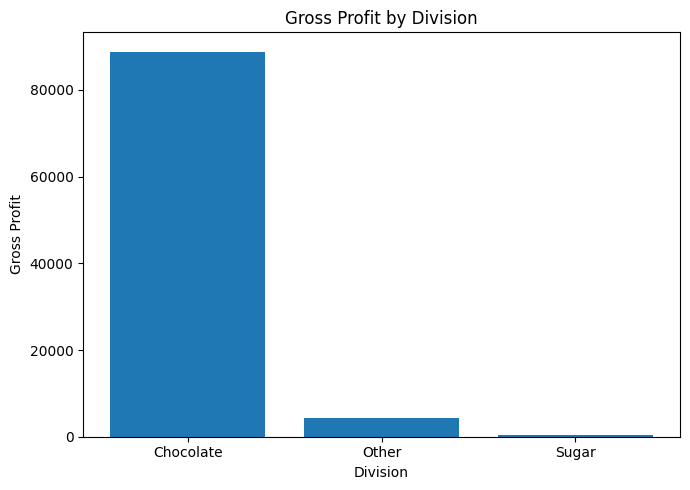

In [71]:
# DIVISION PROFITABILITY

division_analysis = (
    df.groupby("Division")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

division_analysis["Gross Margin %"] = (
    division_analysis["Gross_Profit"]
    / division_analysis["Sales"] * 100
)

display(division_analysis.round(2))

plt.figure(figsize=(7, 5))

plt.bar(
    division_analysis["Division"],
    division_analysis["Gross_Profit"]
)

plt.title("Gross Profit by Division")
plt.xlabel("Division")
plt.ylabel("Gross Profit")

plt.tight_layout()
plt.show()

,Order Date,Sales,Gross_Profit
0,2024-01-01,2093.90,1366.14
1,2024-02-01,1379.87,908.59
2,2024-03-01,4138.90,2671.16
3,2024-04-01,3988.22,2612.81
4,2024-05-01,3951.52,2615.44


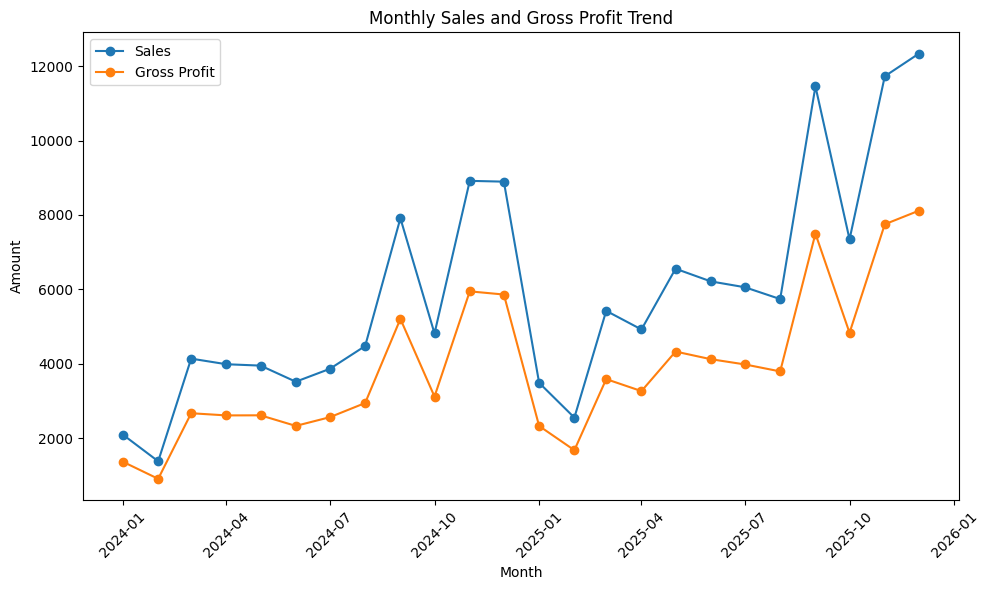

In [72]:
# MONTHLY SALES & PROFIT TREND

monthly_analysis = (
    df.groupby(
        df["Order Date"].dt.to_period("M")
    )
    .agg(
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum")
    )
    .reset_index()
)

monthly_analysis["Order Date"] = (
    monthly_analysis["Order Date"].dt.to_timestamp()
)

display(monthly_analysis.head())

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_analysis["Order Date"],
    monthly_analysis["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_analysis["Order Date"],
    monthly_analysis["Gross_Profit"],
    marker="o",
    label="Gross Profit"
)

plt.title("Monthly Sales and Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
# STEP 72: AUTOMATED BUSINESS INSIGHTS

top_profit_product = product_dashboard.iloc[0]

top_margin_product = product_dashboard.loc[
    product_dashboard["Gross Margin %"].idxmax()
]

top_region = region_analysis.loc[
    region_analysis["Gross_Profit"].idxmax()
]

top_division = division_analysis.loc[
    division_analysis["Gross_Profit"].idxmax()
]

print("=" * 70)
print("             KEY BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"\n1. Highest Gross Profit Product:"
    f"\n   {top_profit_product['Product Name']}"
    f"\n   Gross Profit: ${top_profit_product['Gross_Profit']:,.2f}"
)

print(
    f"\n2. Highest Gross Margin Product:"
    f"\n   {top_margin_product['Product Name']}"
    f"\n   Gross Margin: {top_margin_product['Gross Margin %']:.2f}%"
)

print(
    f"\n3. Highest Gross Profit Region:"
    f"\n   {top_region['Region']}"
    f"\n   Gross Profit: ${top_region['Gross_Profit']:,.2f}"
)

print(
    f"\n4. Highest Gross Profit Division:"
    f"\n   {top_division['Division']}"
    f"\n   Gross Profit: ${top_division['Gross_Profit']:,.2f}"
)

print(
    f"\n5. Overall Gross Margin:"
    f"\n   {gross_margin:.2f}%"
)



             KEY BUSINESS INSIGHTS

1. Highest Gross Profit Product:
   Wonka Bar -Scrumdiddlyumptious
   Gross Profit: $19,357.50

2. Highest Gross Margin Product:
   Everlasting Gobstopper
   Gross Margin: 80.00%

3. Highest Gross Profit Region:
   Pacific
   Gross Profit: $30,485.94

4. Highest Gross Profit Division:
   Chocolate
   Gross Profit: $88,824.62

5. Overall Gross Margin:
   65.91%


In [74]:
# STRATEGIC PRODUCT RECOMMENDATIONS

import pandas as pd
import numpy as np
from IPython.display import display

strategic_products = advanced_product_analysis.copy()

# Median benchmarks
sales_median = strategic_products["Sales"].median()
margin_median = strategic_products["Gross Margin %"].median()

# Create business strategy recommendation
strategic_products["Strategic Recommendation"] = np.select(
    [
        (
            (strategic_products["Sales"] >= sales_median) &
            (strategic_products["Gross Margin %"] >= margin_median)
        ),
        (
            (strategic_products["Sales"] >= sales_median) &
            (strategic_products["Gross Margin %"] < margin_median)
        ),
        (
            (strategic_products["Sales"] < sales_median) &
            (strategic_products["Gross Margin %"] >= margin_median)
        )
    ],
    [
        "Maintain / Increase Inventory & Marketing",
        "Review Pricing and Reduce Cost",
        "Increase Promotion to Grow Sales"
    ],
    default="Review Product / Consider Rationalization"
)

strategic_product_table = strategic_products[
    [
        "Product Name",
        "Sales",
        "Gross_Profit",
        "Gross Margin %",
        "Profit per Unit",
        "Strategic Recommendation"
    ]
].sort_values(
    "Gross_Profit",
    ascending=False
)

print("STRATEGIC PRODUCT RECOMMENDATIONS")


display(strategic_product_table.round(2))

STRATEGIC PRODUCT RECOMMENDATIONS


,Product Name,Sales,Gross_Profit,Gross Margin %,Profit per Unit,Strategic Recommendation
0,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,2.50,Maintain / Increase Inventory & Marketing
1,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33,2.45,Maintain / Increase Inventory & Marketing
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92,2.11,Maintain / Increase Inventory & Marketing
3,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35,2.49,Maintain / Increase Inventory & Marketing
4,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67,2.40,Maintain / Increase Inventory & Marketing
5,Lickable Wallpaper,7860.00,3930.00,50.00,10.00,Review Pricing and Reduce Cost
6,Wonka Gum,597.50,310.70,52.00,0.65,Review Pricing and Reduce Cost
7,Everlasting Gobstopper,130.00,104.00,80.00,8.00,Increase Promotion to Grow Sales
8,Kazookles,1205.75,92.75,7.69,0.25,Review Pricing and Reduce Cost
9,Hair Toffee,76.50,59.50,77.78,3.50,Increase Promotion to Grow Sales


In [75]:
# PROFIT CONCENTRATION ANALYSIS

profit_concentration = (
    advanced_product_analysis[
        ["Product Name", "Gross_Profit"]
    ]
    .sort_values("Gross_Profit", ascending=False)
    .reset_index(drop=True)
)

# Profit contribution
profit_concentration["Profit Contribution %"] = (
    profit_concentration["Gross_Profit"]
    / profit_concentration["Gross_Profit"].sum()
    * 100
)

# Cumulative contribution
profit_concentration["Cumulative Profit %"] = (
    profit_concentration["Profit Contribution %"].cumsum()
)

# Rank products
profit_concentration["Rank"] = (
    np.arange(1, len(profit_concentration) + 1)
)

# Top 10 products
top_10_concentration = profit_concentration.head(10)

top_10_profit_share = (
    top_10_concentration["Gross_Profit"].sum()
    / profit_concentration["Gross_Profit"].sum()
    * 100
)

print("PROFIT CONCENTRATION ANALYSIS")

display(top_10_concentration.round(2))

print(
    f"\nTop 10 Products Contribution to Total Profit: "
    f"{top_10_profit_share:.2f}%"
)

print(
    f"Total Products Analyzed: "
    f"{len(profit_concentration)}"
)

PROFIT CONCENTRATION ANALYSIS


,Product Name,Gross_Profit,Profit Contribution %,Cumulative Profit %,Rank
0,Wonka Bar -Scrumdiddlyumptious,19357.50,20.72,20.72,1
1,Wonka Bar - Triple Dazzle Caramel,18610.20,19.92,40.63,2
2,Wonka Bar - Milk Chocolate,17443.37,18.67,59.30,3
3,Wonka Bar - Nutty Crunch Surprise,16819.95,18.00,77.30,4
4,Wonka Bar - Fudge Mallows,16593.60,17.76,95.06,5
5,Lickable Wallpaper,3930.00,4.21,99.26,6
6,Wonka Gum,310.70,0.33,99.60,7
7,Everlasting Gobstopper,104.00,0.11,99.71,8
8,Kazookles,92.75,0.10,99.81,9
9,Hair Toffee,59.50,0.06,99.87,10



Top 10 Products Contribution to Total Profit: 99.87%
Total Products Analyzed: 15


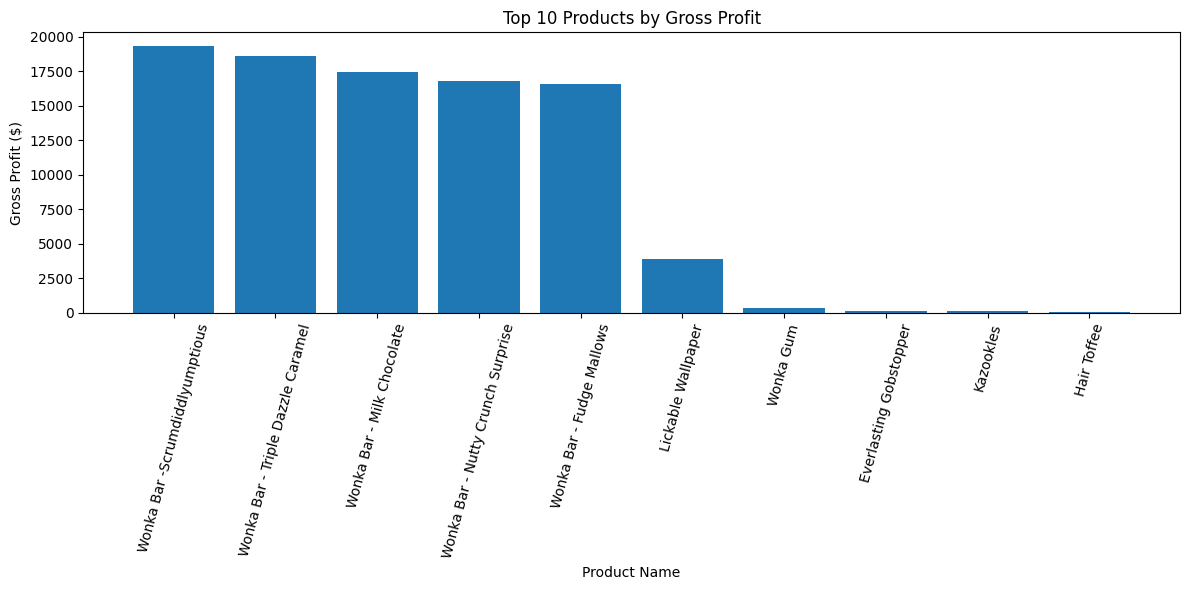

In [76]:
# TOP 10 PRODUCT PROFIT CONTRIBUTION VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_concentration["Product Name"],
    top_10_concentration["Gross_Profit"]
)

plt.title("Top 10 Products by Gross Profit")
plt.xlabel("Product Name")
plt.ylabel("Gross Profit ($)")

plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [77]:
# LOW-MARGIN PRODUCT OPPORTUNITY ANALYSIS

median_sales = advanced_product_analysis["Sales"].median()
median_margin = advanced_product_analysis["Gross Margin %"].median()

low_margin_opportunities = advanced_product_analysis[
    (
        advanced_product_analysis["Sales"] >= median_sales
    )
    &
    (
        advanced_product_analysis["Gross Margin %"] < median_margin
    )
].copy()

low_margin_opportunities = (
    low_margin_opportunities
    .sort_values("Sales", ascending=False)
)

print("=" * 75)
print("        HIGH-SALES / LOW-MARGIN PRODUCT OPPORTUNITIES")
print("=" * 75)

if len(low_margin_opportunities) > 0:

    display(
        low_margin_opportunities[
            [
                "Product Name",
                "Sales",
                "Cost",
                "Gross_Profit",
                "Gross Margin %",
                "Profit per Unit"
            ]
        ].round(2)
    )

else:
    print("No High-Sales / Low-Margin products found.")

        HIGH-SALES / LOW-MARGIN PRODUCT OPPORTUNITIES


,Product Name,Sales,Cost,Gross_Profit,Gross Margin %,Profit per Unit
5,Lickable Wallpaper,7860.00,3930.0,3930.00,50.00,10.00
8,Kazookles,1205.75,1113.0,92.75,7.69,0.25
6,Wonka Gum,597.50,286.8,310.70,52.00,0.65


In [78]:
# REGIONAL STRATEGIC ANALYSIS

regional_strategy = region_analysis.copy()

# Calculate contribution to total sales and profit
regional_strategy["Sales Contribution %"] = (
    regional_strategy["Sales"]
    / regional_strategy["Sales"].sum()
    * 100
)

regional_strategy["Profit Contribution %"] = (
    regional_strategy["Gross_Profit"]
    / regional_strategy["Gross_Profit"].sum()
    * 100
)

# Rank regions
regional_strategy["Profit Rank"] = (
    regional_strategy["Gross_Profit"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

regional_strategy = regional_strategy.sort_values(
    "Gross_Profit",
    ascending=False
)

print("=" * 75)
print("                  REGIONAL STRATEGIC ANALYSIS")
print("=" * 75)

display(
    regional_strategy[
        [
            "Region",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Sales Contribution %",
            "Profit Contribution %",
            "Profit Rank"
        ]
    ].round(2)
)

                  REGIONAL STRATEGIC ANALYSIS


,Region,Sales,Gross_Profit,Gross Margin %,Sales Contribution %,Profit Contribution %,Profit Rank
3,Pacific,46301.53,30485.94,65.84,32.66,32.63,1
0,Atlantic,41197.24,26973.70,65.47,29.06,28.87,2
2,Interior,32037.60,21282.49,66.43,22.60,22.78,3
1,Gulf,22247.26,14700.67,66.08,15.69,15.73,4


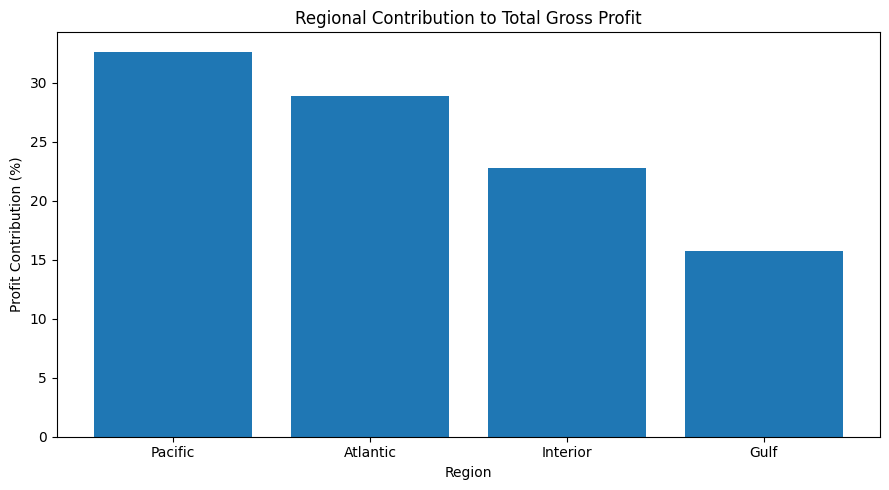

In [79]:
# REGIONAL PROFIT CONTRIBUTION CHART

plt.figure(figsize=(9, 5))

plt.bar(
    regional_strategy["Region"],
    regional_strategy["Profit Contribution %"]
)

plt.title("Regional Contribution to Total Gross Profit")
plt.xlabel("Region")
plt.ylabel("Profit Contribution (%)")

plt.tight_layout()
plt.show()

In [80]:
# DIVISION STRATEGIC ANALYSIS

division_strategy = division_analysis.copy()

division_strategy["Sales Contribution %"] = (
    division_strategy["Sales"]
    / division_strategy["Sales"].sum()
    * 100
)

division_strategy["Profit Contribution %"] = (
    division_strategy["Gross_Profit"]
    / division_strategy["Gross_Profit"].sum()
    * 100
)

division_strategy["Profit Rank"] = (
    division_strategy["Gross_Profit"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

division_strategy = division_strategy.sort_values(
    "Gross_Profit",
    ascending=False
)

print("=" * 75)
print("                  DIVISION STRATEGIC ANALYSIS")
print("=" * 75)

display(
    division_strategy[
        [
            "Division",
            "Sales",
            "Gross_Profit",
            "Gross Margin %",
            "Sales Contribution %",
            "Profit Contribution %",
            "Profit Rank"
        ]
    ].round(2)
)

                  DIVISION STRATEGIC ANALYSIS


,Division,Sales,Gross_Profit,Gross Margin %,Sales Contribution %,Profit Contribution %,Profit Rank
0,Chocolate,131692.90,88824.62,67.45,92.88,95.06,1
1,Other,9663.25,4333.45,44.84,6.82,4.64,2
2,Sugar,427.48,284.73,66.61,0.30,0.30,3


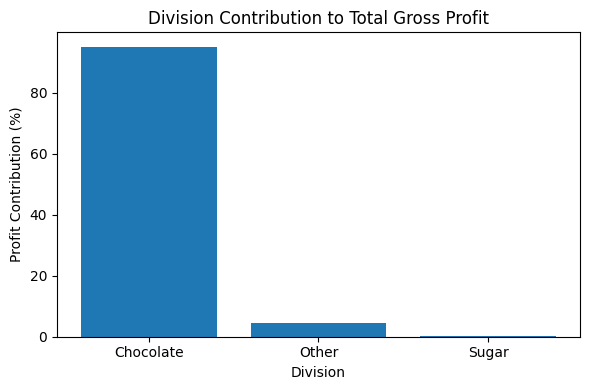

In [81]:
# DIVISION PROFIT CONTRIBUTION VISUALIZATION

plt.figure(figsize=(6, 4))

plt.bar(
    division_strategy["Division"],
    division_strategy["Profit Contribution %"]
)

plt.title("Division Contribution to Total Gross Profit")
plt.xlabel("Division")
plt.ylabel("Profit Contribution (%)")

plt.tight_layout()
plt.show()

In [82]:
# MONTHLY SALES & PROFIT GROWTH ANALYSIS

monthly_growth = monthly_analysis.copy()

monthly_growth = monthly_growth.sort_values(
    "Order Date"
)

# Month-over-month percentage change
monthly_growth["Sales Growth %"] = (
    monthly_growth["Sales"]
    .pct_change()
    * 100
)

monthly_growth["Profit Growth %"] = (
    monthly_growth["Gross_Profit"]
    .pct_change()
    * 100
)

print("=" * 75)
print("               MONTHLY BUSINESS GROWTH ANALYSIS")
print("=" * 75)

display(monthly_growth.round(2))

               MONTHLY BUSINESS GROWTH ANALYSIS


,Order Date,Sales,Gross_Profit,Sales Growth %,Profit Growth %
0,2024-01-01,2093.90,1366.14,NaN,NaN
1,2024-02-01,1379.87,908.59,-34.10,-33.49
2,2024-03-01,4138.90,2671.16,199.95,193.99
3,2024-04-01,3988.22,2612.81,-3.64,-2.18
4,2024-05-01,3951.52,2615.44,-0.92,0.10
5,2024-06-01,3518.76,2330.72,-10.95,-10.89
6,2024-07-01,3865.38,2565.26,9.85,10.06
7,2024-08-01,4477.65,2945.87,15.84,14.84
8,2024-09-01,7912.10,5206.70,76.70,76.75
9,2024-10-01,4815.98,3119.46,-39.13,-40.09


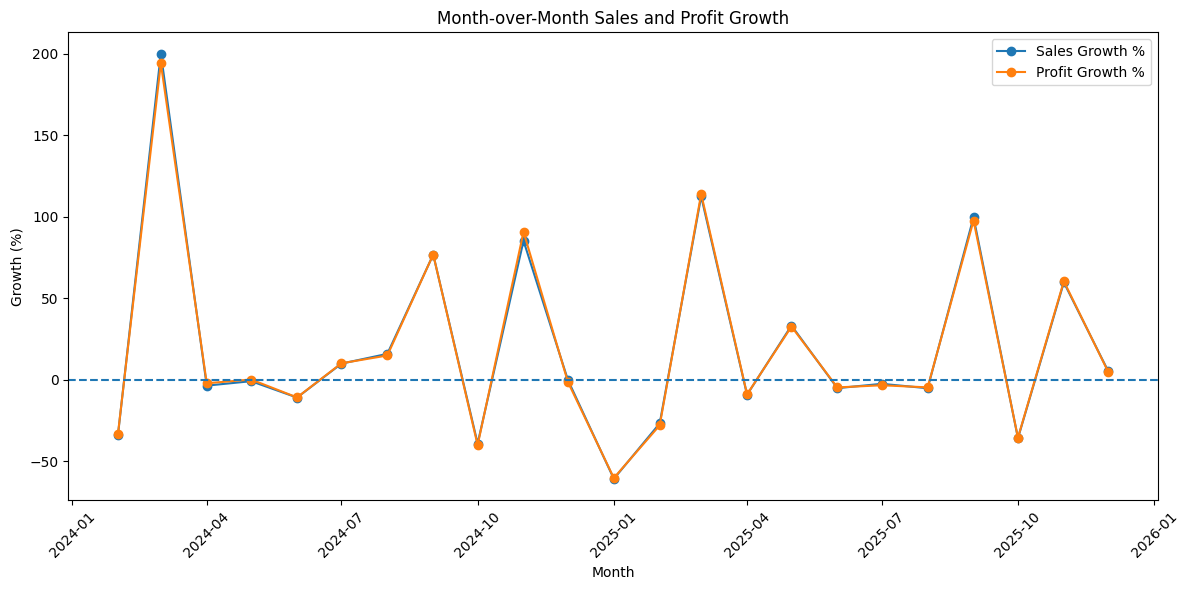

In [83]:
# MONTHLY SALES AND PROFIT GROWTH VISUALIZATION

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth["Order Date"],
    monthly_growth["Sales Growth %"],
    marker="o",
    label="Sales Growth %"
)

plt.plot(
    monthly_growth["Order Date"],
    monthly_growth["Profit Growth %"],
    marker="o",
    label="Profit Growth %"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Month-over-Month Sales and Profit Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [84]:
# FINAL BUSINESS RECOMMENDATIONS

business_recommendations = pd.DataFrame({

    "Business Area": [
        "High Sales - High Margin Products",
        "High Sales - Low Margin Products",
        "Low Sales - High Margin Products",
        "Low Sales - Low Margin Products",
        "Top Profit Products",
        "Regional Performance",
        "Division Performance",
        "Margin Management"
    ],

    "Recommended Action": [
        "Maintain strong inventory levels and increase marketing investment.",
        "Review pricing, supplier costs and discount strategy to improve margins.",
        "Increase promotional activities to grow sales volume.",
        "Review product viability and consider rationalization if performance remains weak.",
        "Protect availability of major profit-generating products and prevent stock-outs.",
        "Increase focus on high-performing regions while investigating weaker regions.",
        "Allocate resources toward divisions generating strong profit contribution.",
        "Monitor product margins regularly and reduce avoidable product-level costs."
    ]

})

print("FINAL BUSINESS RECOMMENDATIONS")
display(business_recommendations)

FINAL BUSINESS RECOMMENDATIONS


,Business Area,Recommended Action
0,High Sales - High Margin Products,Maintain strong inventory levels and increase ...
1,High Sales - Low Margin Products,"Review pricing, supplier costs and discount st..."
2,Low Sales - High Margin Products,Increase promotional activities to grow sales ...
3,Low Sales - Low Margin Products,Review product viability and consider rational...
4,Top Profit Products,Protect availability of major profit-generatin...
5,Regional Performance,Increase focus on high-performing regions whil...
6,Division Performance,Allocate resources toward divisions generating...
7,Margin Management,Monitor product margins regularly and reduce a...


In [85]:
# FINAL EXECUTIVE SUMMARY

best_product_profit = advanced_product_analysis.iloc[0]

best_margin_product = advanced_product_analysis.loc[
    advanced_product_analysis["Gross Margin %"].idxmax()
]

best_region = regional_strategy.iloc[0]

best_division = division_strategy.iloc[0]

print("NASSAU CANDY DISTRIBUTOR - FINAL EXECUTIVE SUMMARY")
print(f"""
OVERALL BUSINESS PERFORMANCE

Total Sales          : ${total_sales:,.2f}
Total Cost           : ${total_cost:,.2f}
Total Gross Profit   : ${total_profit:,.2f}
Overall Gross Margin : {gross_margin:.2f}%
Total Units Sold     : {total_units:,}
Total Orders         : {total_orders:,}
Total Customers      : {total_customers:,}
Profit per Unit      : ${profit_per_unit:.2f}


PRODUCT PERFORMANCE

Highest Profit Product:
{best_product_profit['Product Name']}

Gross Profit:
${best_product_profit['Gross_Profit']:,.2f}

Highest Margin Product:
{best_margin_product['Product Name']}

Gross Margin:
{best_margin_product['Gross Margin %']:.2f}%


REGIONAL PERFORMANCE

Top Region:
{best_region['Region']}

Regional Gross Profit:
${best_region['Gross_Profit']:,.2f}


DIVISION PERFORMANCE

Top Division:
{best_division['Division']}

Division Gross Profit:
${best_division['Gross_Profit']:,.2f}


PROFIT CONCENTRATION

Top 10 Products Contribution:
{top_10_profit_share:.2f}% of total gross profit
""")



NASSAU CANDY DISTRIBUTOR - FINAL EXECUTIVE SUMMARY

OVERALL BUSINESS PERFORMANCE

Total Sales          : $141,783.63
Total Cost           : $48,340.83
Total Gross Profit   : $93,442.80
Overall Gross Margin : 65.91%
Total Units Sold     : 38,654
Total Orders         : 8,549
Total Customers      : 5,044
Profit per Unit      : $2.42


PRODUCT PERFORMANCE

Highest Profit Product:
Wonka Bar -Scrumdiddlyumptious

Gross Profit:
$19,357.50

Highest Margin Product:
Everlasting Gobstopper

Gross Margin:
80.00%


REGIONAL PERFORMANCE

Top Region:
Pacific

Regional Gross Profit:
$30,485.94


DIVISION PERFORMANCE

Top Division:
Chocolate

Division Gross Profit:
$88,824.62


PROFIT CONCENTRATION

Top 10 Products Contribution:
99.87% of total gross profit



In [86]:
# FINAL PROJECT KPI SUMMARY TABLE

final_kpi_summary = pd.DataFrame({

    "KPI": [
        "Total Sales",
        "Total Cost",
        "Gross Profit",
        "Gross Margin %",
        "Units Sold",
        "Orders",
        "Customers",
        "Profit per Unit",
        "Top Profit Product",
        "Top Margin Product",
        "Top Region",
        "Top Division",
        "Top 10 Product Profit Contribution %"
    ],

    "Value": [
        f"${total_sales:,.2f}",
        f"${total_cost:,.2f}",
        f"${total_profit:,.2f}",
        f"{gross_margin:.2f}%",
        f"{total_units:,}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"${profit_per_unit:.2f}",
        best_product_profit["Product Name"],
        best_margin_product["Product Name"],
        best_region["Region"],
        best_division["Division"],
        f"{top_10_profit_share:.2f}%"
    ]

})

print("FINAL PROJECT KPI SUMMARY")

display(final_kpi_summary)

FINAL PROJECT KPI SUMMARY


,KPI,Value
0,Total Sales,"$141,783.63"
1,Total Cost,"$48,340.83"
2,Gross Profit,"$93,442.80"
3,Gross Margin %,65.91%
4,Units Sold,"38,654"
5,Orders,"8,549"
6,Customers,"5,044"
7,Profit per Unit,$2.42
8,Top Profit Product,Wonka Bar -Scrumdiddlyumptious
9,Top Margin Product,Everlasting Gobstopper


In [87]:
df["Profit Margin %"] = (
    df["Gross Profit"] / df["Sales"]
) * 100

df["Profit Margin %"] = df["Profit Margin %"].round(2)

df[["Sales", "Gross Profit", "Profit Margin %"]].head()

,Sales,Gross Profit,Profit Margin %
0,6.50,4.22,64.92
1,7.50,4.90,65.33
2,10.47,7.47,71.35
3,10.80,7.50,69.44
4,11.25,7.35,65.33


In [88]:
division_analysis = (
    df.groupby("Division")
      .agg(
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

division_analysis["Profit Margin %"] = (
    division_analysis["Gross_Profit"] /
    division_analysis["Sales"] * 100
)

division_analysis = division_analysis.round(2)

division_analysis

,Division,Sales,Gross_Profit,Units,Profit Margin %
0,Chocolate,131692.90,88824.62,37275,67.45
1,Other,9663.25,4333.45,1242,44.84
2,Sugar,427.48,284.73,137,66.61


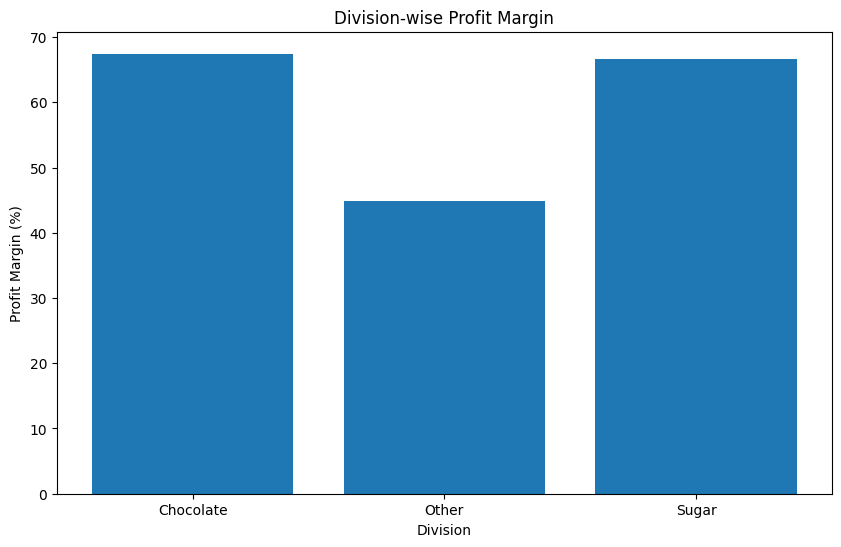

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    division_analysis["Division"],
    division_analysis["Profit Margin %"]
)

plt.title("Division-wise Profit Margin")
plt.xlabel("Division")
plt.ylabel("Profit Margin (%)")

plt.show()

In [90]:
product_analysis = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum"),
          Orders=("Order ID", "count")
      )
      .reset_index()
)

product_analysis["Profit Margin %"] = (
    product_analysis["Gross_Profit"] /
    product_analysis["Sales"] * 100
)

product_analysis["Profit Margin %"] = (
    product_analysis["Profit Margin %"].round(2)
)

product_analysis

,Product Name,Sales,Gross_Profit,Units,Orders,Profit Margin %
0,Everlasting Gobstopper,130.00,104.00,13,3,80.00
1,Fizzy Lifting Drinks,78.75,47.25,21,6,60.00
2,Fun Dip,12.00,4.80,8,3,40.00
3,Hair Toffee,76.50,59.50,17,4,77.78
4,Kazookles,1205.75,92.75,371,96,7.69
5,Laffy Taffy,53.73,33.48,27,10,62.31
6,Lickable Wallpaper,7860.00,3930.00,393,94,50.00
7,Nerds,15.00,7.00,10,4,46.67
8,SweeTARTS,61.50,28.70,41,10,46.67
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,1818,66.67


In [91]:
top10_products = product_analysis.sort_values(
    "Gross_Profit",
    ascending=False
).head(10)

top10_products

,Product Name,Sales,Gross_Profit,Units,Orders,Profit Margin %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,7743,2064,69.44
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,2015,65.33
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,2137,64.92
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,1810,71.35
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,1818,66.67
6,Lickable Wallpaper,7860.00,3930.00,393,94,50.00
14,Wonka Gum,597.50,310.70,478,120,52.00
0,Everlasting Gobstopper,130.00,104.00,13,3,80.00
4,Kazookles,1205.75,92.75,371,96,7.69
3,Hair Toffee,76.50,59.50,17,4,77.78


In [92]:
bottom10_products = product_analysis.sort_values(
    "Gross_Profit",
    ascending=True
).head(10)

bottom10_products

,Product Name,Sales,Gross_Profit,Units,Orders,Profit Margin %
2,Fun Dip,12.00,4.80,8,3,40.00
7,Nerds,15.00,7.00,10,4,46.67
8,SweeTARTS,61.50,28.70,41,10,46.67
5,Laffy Taffy,53.73,33.48,27,10,62.31
1,Fizzy Lifting Drinks,78.75,47.25,21,6,60.00
3,Hair Toffee,76.50,59.50,17,4,77.78
4,Kazookles,1205.75,92.75,371,96,7.69
0,Everlasting Gobstopper,130.00,104.00,13,3,80.00
14,Wonka Gum,597.50,310.70,478,120,52.00
6,Lickable Wallpaper,7860.00,3930.00,393,94,50.00


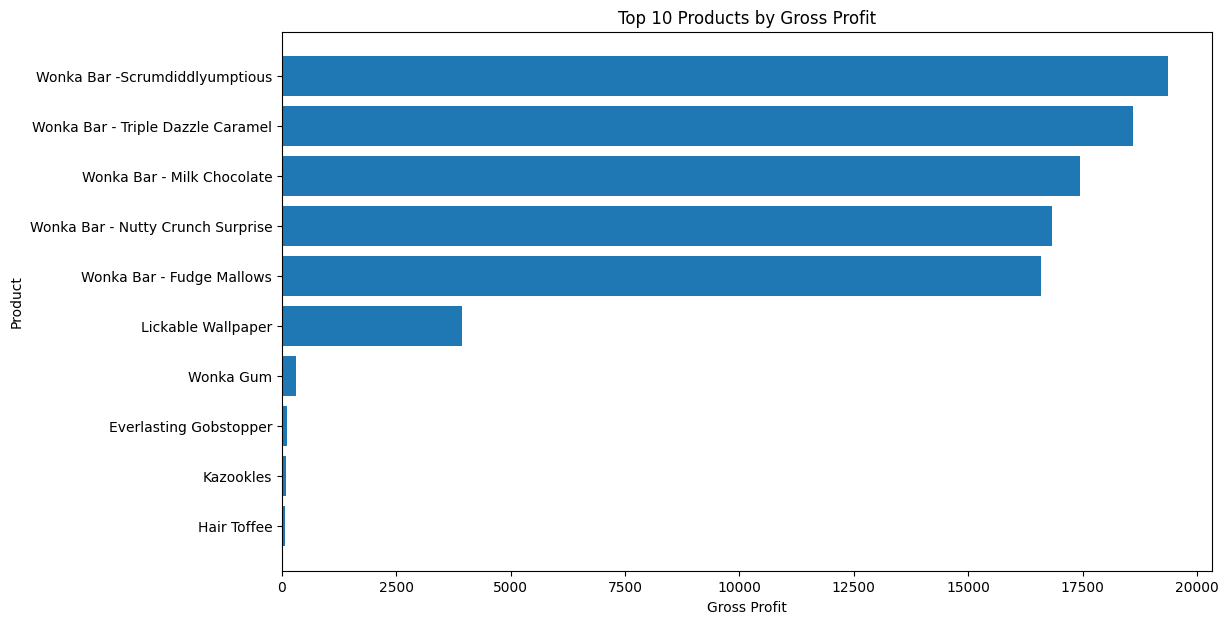

In [93]:
plt.figure(figsize=(12,7))

plt.barh(
    top10_products["Product Name"],
    top10_products["Gross_Profit"]
)

plt.title("Top 10 Products by Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

In [94]:
region_analysis = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

region_analysis["Profit Margin %"] = (
    region_analysis["Gross_Profit"] /
    region_analysis["Sales"] * 100
)

region_analysis.round(2)

,Region,Sales,Gross_Profit,Units,Profit Margin %
0,Atlantic,41197.24,26973.70,11159,65.47
1,Gulf,22247.26,14700.67,6209,66.08
2,Interior,32037.60,21282.49,8820,66.43
3,Pacific,46301.53,30485.94,12466,65.84


In [95]:
state_analysis = (
    df.groupby("State/Province")
      .agg(
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

state_analysis["Profit Margin %"] = (
    state_analysis["Gross_Profit"] /
    state_analysis["Sales"] * 100
)

state_analysis = state_analysis.round(2)

state_analysis.sort_values(
    "Profit Margin %",
    ascending=False
).head(10)

,State/Province,Sales,Gross_Profit,Units,Profit Margin %
58,Wyoming,13.96,9.96,4,71.35
35,Newfoundland and Labrador,162.00,112.50,45,69.44
49,South Dakota,151.34,104.14,42,68.81
30,New Brunswick,172.72,118.72,48,68.74
56,West Virginia,63.97,43.89,18,68.61
4,British Columbia,290.90,198.30,81,68.17
44,Prince Edward Island,130.10,88.66,38,68.15
16,Kansas,263.18,179.22,74,68.10
40,Oklahoma,877.65,595.91,247,67.90
28,Nebraska,483.53,327.89,136,67.81


In [96]:
from scipy.stats import pearsonr

corr_sales_profit, p_sales_profit = pearsonr(
    df["Sales"],
    df["Gross Profit"]
)

print("Sales vs Gross Profit")
print("Correlation:", round(corr_sales_profit, 3))
print("P-value:", round(p_sales_profit, 5))

Sales vs Gross Profit
Correlation: 0.976
P-value: 0.0


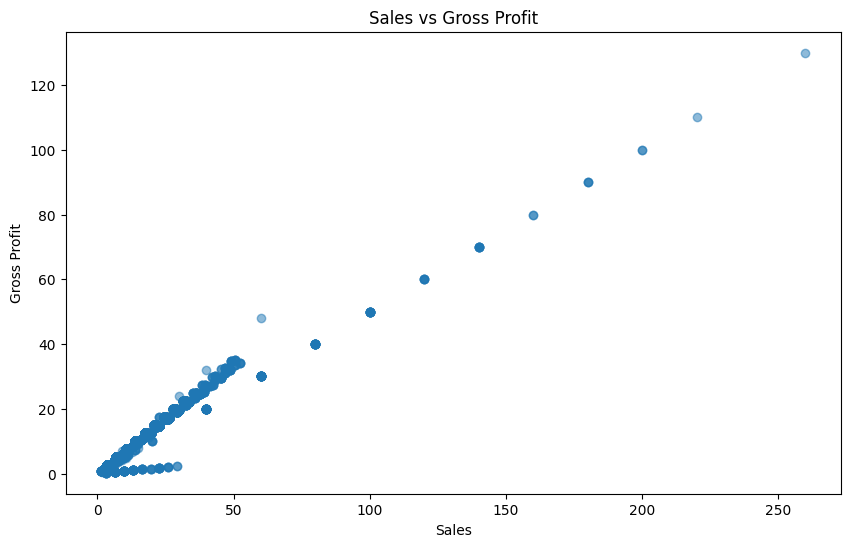

In [97]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Sales"],
    df["Gross Profit"],
    alpha=0.5
)

plt.title("Sales vs Gross Profit")
plt.xlabel("Sales")
plt.ylabel("Gross Profit")

plt.show()

In [98]:
corr_units_margin, p_units_margin = pearsonr(
    df["Units"],
    df["Profit Margin %"]
)

print("Units vs Profit Margin %")
print("Correlation:", round(corr_units_margin, 3))
print("P-value:", round(p_units_margin, 5))

Units vs Profit Margin %
Correlation: -0.014
P-value: 0.16695


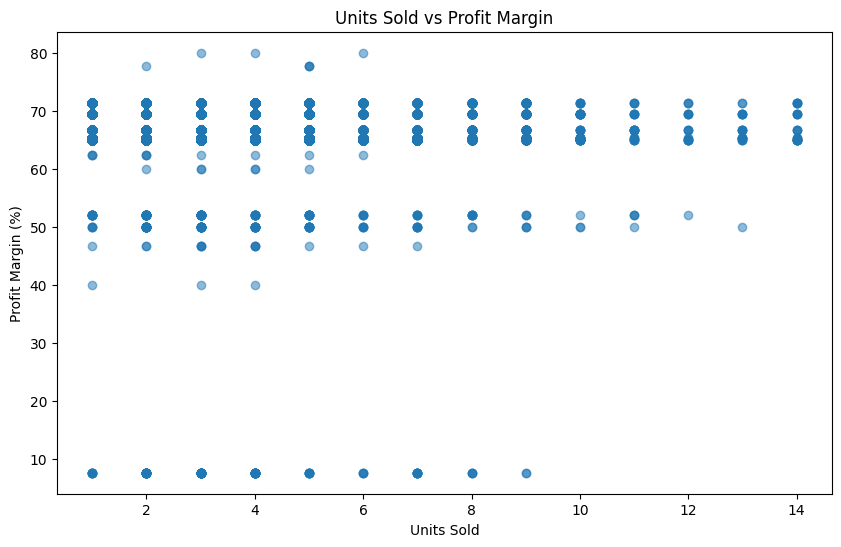

In [99]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Units"],
    df["Profit Margin %"],
    alpha=0.5
)

plt.title("Units Sold vs Profit Margin")
plt.xlabel("Units Sold")
plt.ylabel("Profit Margin (%)")

plt.show()

In [100]:
df["Month"] = df["Order Date"].dt.to_period("M")

monthly_profit = (
    df.groupby("Month")["Gross Profit"]
      .sum()
      .reset_index()
)

monthly_profit["Month"] = (
    monthly_profit["Month"].astype(str)
)

monthly_profit.head()

,Month,Gross Profit
0,2024-01,1366.14
1,2024-02,908.59
2,2024-03,2671.16
3,2024-04,2612.81
4,2024-05,2615.44


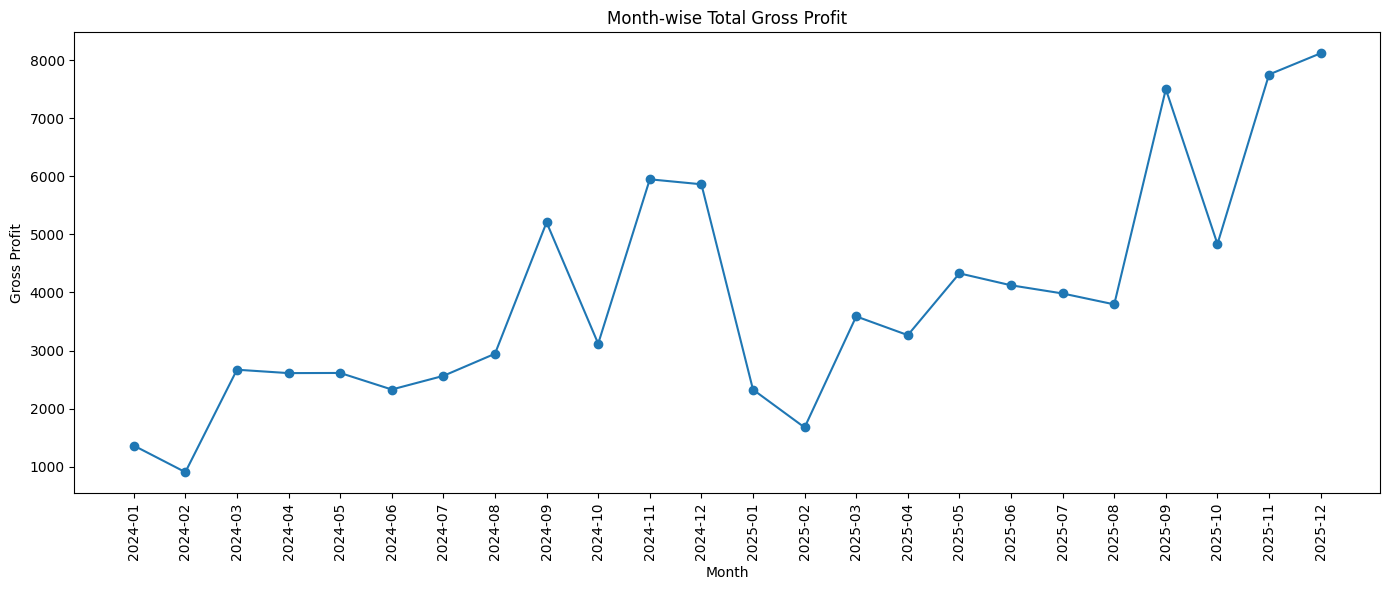

In [101]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_profit["Month"],
    monthly_profit["Gross Profit"],
    marker="o"
)

plt.title("Month-wise Total Gross Profit")
plt.xlabel("Month")
plt.ylabel("Gross Profit")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [102]:
state_division_profit = pd.pivot_table(
    df,
    values="Gross Profit",
    index="State/Province",
    columns="Division",
    aggfunc="sum"
)

state_division_sales = pd.pivot_table(
    df,
    values="Sales",
    index="State/Province",
    columns="Division",
    aggfunc="sum"
)

state_division_margin = (
    state_division_profit /
    state_division_sales
) * 100

state_division_margin = state_division_margin.round(2)

state_division_margin

Division,Chocolate,Other,Sugar
State/Province,,,
Alabama,67.23,41.97,NaN
Alberta,67.45,50.00,NaN
Arizona,67.11,48.95,71.85
Arkansas,67.14,50.12,NaN
British Columbia,68.17,NaN,NaN
California,67.41,43.92,71.23
Colorado,67.51,43.86,80.00
Connecticut,67.33,16.73,62.31
Delaware,67.12,37.21,46.67


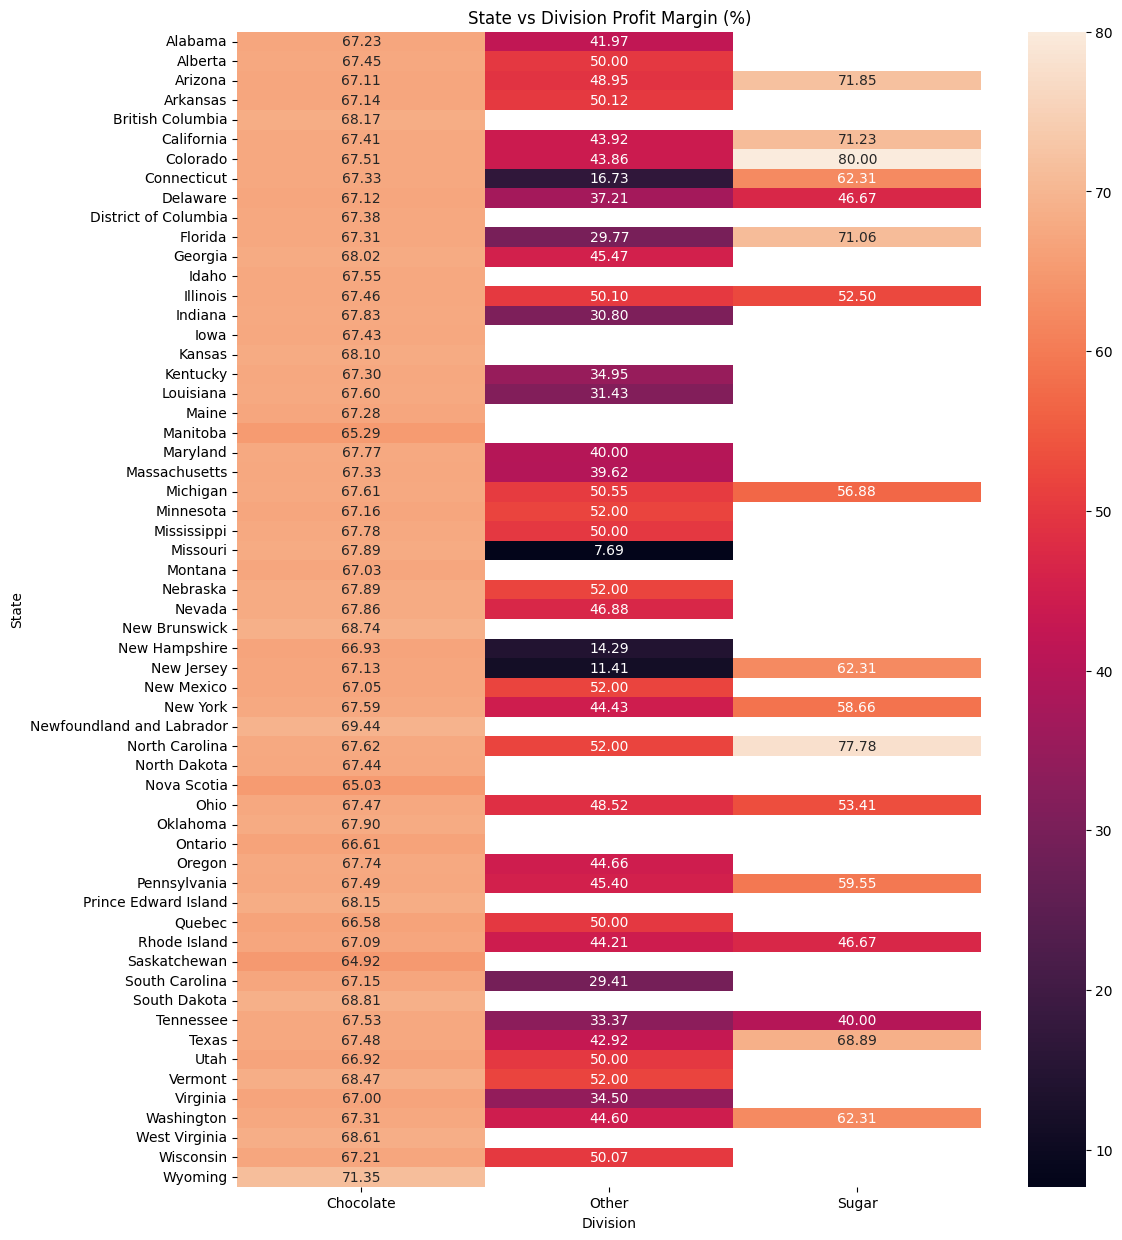

In [103]:
import seaborn as sns

plt.figure(figsize=(12,15))

sns.heatmap(
    state_division_margin,
    annot=True,
    fmt=".2f"
)

plt.title("State vs Division Profit Margin (%)")
plt.xlabel("Division")
plt.ylabel("State")

plt.show()

In [104]:
from sklearn.preprocessing import MinMaxScaler

product_score = product_analysis.copy()

scaler = MinMaxScaler()

product_score[
    ["Sales_Normalized", "Units_Normalized"]
] = scaler.fit_transform(
    product_score[["Sales", "Units"]]
)

product_score["Overall Product Score"] = (
    (product_score["Profit Margin %"] / 100) * 0.50
    + product_score["Sales_Normalized"] * 0.30
    + product_score["Units_Normalized"] * 0.20
)

product_score["Overall Product Score"] = (
    product_score["Overall Product Score"].round(3)
)

product_score = product_score.sort_values(
    "Overall Product Score",
    ascending=False
)

product_score[
    [
        "Product Name",
        "Sales",
        "Units",
        "Profit Margin %",
        "Overall Product Score"
    ]
]

,Product Name,Sales,Units,Profit Margin %,Overall Product Score
13,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,69.44,0.828
12,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,65.33,0.810
10,Wonka Bar - Milk Chocolate,26867.75,8267,64.92,0.808
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,71.35,0.768
9,Wonka Bar - Fudge Mallows,24890.40,6914,66.67,0.763
0,Everlasting Gobstopper,130.00,13,80.00,0.401
3,Hair Toffee,76.50,17,77.78,0.390
6,Lickable Wallpaper,7860.00,393,50.00,0.342
5,Laffy Taffy,53.73,27,62.31,0.312
1,Fizzy Lifting Drinks,78.75,21,60.00,0.301


In [105]:
# Business Recommendations

#Based on the profitability, margin, product, regional and time-based analysis, the following business recommendations are proposed.

In [106]:
# 1. HIGH MARGIN PRODUCTS

high_margin = product_score.sort_values(
    "Profit Margin %",
    ascending=False
).head(3)

print("\n1. HIGH-MARGIN PRODUCTS")
print("-" * 80)

for _, row in high_margin.iterrows():
    print(
        f"• {row['Product Name']} | "
        f"Profit Margin: {row['Profit Margin %']:.2f}% | "
        f"Sales: ${row['Sales']:,.2f} | "
        f"Units: {row['Units']:,.0f}"
    )

print(
    "\nRecommendation: High-margin products should be considered "
    "for targeted promotions and cross-selling."
)

# 2. HIGH SALES PRODUCTS

high_sales = product_score.sort_values(
    "Sales",
    ascending=False
).head(3)

print("\n2. HIGH-SALES PRODUCTS")
print("-" * 80)

for _, row in high_sales.iterrows():
    print(
        f"• {row['Product Name']} | "
        f"Sales: ${row['Sales']:,.2f} | "
        f"Profit Margin: {row['Profit Margin %']:.2f}%"
    )

print(
    "\nRecommendation: Maintain inventory availability for "
    "high-sales products and monitor their margins."
)

# 3. LOW MARGIN PRODUCTS

low_margin = product_score.sort_values(
    "Profit Margin %",
    ascending=True
).head(3)

print("\n3. LOW-MARGIN PRODUCTS")
print("-" * 80)

for _, row in low_margin.iterrows():
    print(
        f"• {row['Product Name']} | "
        f"Profit Margin: {row['Profit Margin %']:.2f}% | "
        f"Sales: ${row['Sales']:,.2f}"
    )

print(
    "\nRecommendation: Review pricing, product cost and "
    "discounting strategy for low-margin products."
)

# 4. REGIONAL PERFORMANCE

best_regions = region_analysis.sort_values(
    "Profit Margin %",
    ascending=False
).head(3)

print("\n4. HIGH-MARGIN REGIONS")
print("-" * 80)

for _, row in best_regions.iterrows():
    print(
        f"• {row['Region']} | "
        f"Profit Margin: {row['Profit Margin %']:.2f}% | "
        f"Sales: ${row['Sales']:,.2f}"
    )

print(
    "\nRecommendation: Maintain strong distribution and "
    "inventory availability in high-margin regions."
)

# 5. HIGHEST PROFIT MONTH

best_month = monthly_profit.loc[
    monthly_profit["Gross Profit"].idxmax()
]

print("\n5. MONTHLY PROFIT TREND")
print("-" * 80)

print(
    f"• Highest-profit month: {best_month['Month']} | "
    f"Gross Profit: ${best_month['Gross Profit']:,.2f}"
)

print(
    "\nRecommendation: Use high-profit periods for "
    "seasonal inventory and promotional planning."
)



1. HIGH-MARGIN PRODUCTS
--------------------------------------------------------------------------------
• Everlasting Gobstopper | Profit Margin: 80.00% | Sales: $130.00 | Units: 13
• Hair Toffee | Profit Margin: 77.78% | Sales: $76.50 | Units: 17
• Wonka Bar - Nutty Crunch Surprise | Profit Margin: 71.35% | Sales: $23,574.95 | Units: 6,755

Recommendation: High-margin products should be considered for targeted promotions and cross-selling.

2. HIGH-SALES PRODUCTS
--------------------------------------------------------------------------------
• Wonka Bar - Triple Dazzle Caramel | Sales: $28,485.00 | Profit Margin: 65.33%
• Wonka Bar -Scrumdiddlyumptious | Sales: $27,874.80 | Profit Margin: 69.44%
• Wonka Bar - Milk Chocolate | Sales: $26,867.75 | Profit Margin: 64.92%

Recommendation: Maintain inventory availability for high-sales products and monitor their margins.

3. LOW-MARGIN PRODUCTS
--------------------------------------------------------------------------------
• Kazookles |

In [107]:
# Profit Concentration / Pareto Analysis

#This analysis identifies the products contributing to approximately 80% of total sales and 80% of total gross profit.

In [108]:
# Product-level Sales and Profit

pareto = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum")
      )
      .reset_index()
)

# Sort by Sales
pareto_sales = pareto.sort_values(
    "Sales",
    ascending=False
).reset_index(drop=True)

# Cumulative Sales %
pareto_sales["Cumulative Sales %"] = (
    pareto_sales["Sales"].cumsum()
    / pareto_sales["Sales"].sum()
) * 100

# Sort by Profit
pareto_profit = pareto.sort_values(
    "Gross_Profit",
    ascending=False
).reset_index(drop=True)

# Cumulative Profit %
pareto_profit["Cumulative Profit %"] = (
    pareto_profit["Gross_Profit"].cumsum()
    / pareto_profit["Gross_Profit"].sum()
) * 100

print("Sales Pareto Analysis")
display(pareto_sales)

print("\nProfit Pareto Analysis")
display(pareto_profit)

Sales Pareto Analysis


,Product Name,Sales,Gross_Profit,Cumulative Sales %
0,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,20.090472
1,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,39.750569
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,58.700394
3,Wonka Bar - Fudge Mallows,24890.40,16593.60,76.255595
4,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,92.883008
5,Lickable Wallpaper,7860.00,3930.00,98.426666
6,Kazookles,1205.75,92.75,99.277082
7,Wonka Gum,597.50,310.70,99.698498
8,Everlasting Gobstopper,130.00,104.00,99.790187
9,Fizzy Lifting Drinks,78.75,47.25,99.845730



Profit Pareto Analysis


,Product Name,Sales,Gross_Profit,Cumulative Profit %
0,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,40.632023
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,59.299454
3,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,77.299717
4,Wonka Bar - Fudge Mallows,24890.40,16593.60,95.057747
5,Lickable Wallpaper,7860.00,3930.00,99.263528
6,Wonka Gum,597.50,310.70,99.596031
7,Everlasting Gobstopper,130.00,104.00,99.707329
8,Kazookles,1205.75,92.75,99.806588
9,Hair Toffee,76.50,59.50,99.870263


In [109]:
sales_80 = pareto_sales[
    pareto_sales["Cumulative Sales %"] <= 80
]

profit_80 = pareto_profit[
    pareto_profit["Cumulative Profit %"] <= 80
]

print("Products contributing up to approximately 80% of Sales:")
display(sales_80)

print("\nProducts contributing up to approximately 80% of Gross Profit:")
display(profit_80)

Products contributing up to approximately 80% of Sales:


,Product Name,Sales,Gross_Profit,Cumulative Sales %
0,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,20.090472
1,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,39.750569
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,58.700394
3,Wonka Bar - Fudge Mallows,24890.40,16593.60,76.255595



Products contributing up to approximately 80% of Gross Profit:


,Product Name,Sales,Gross_Profit,Cumulative Profit %
0,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,40.632023
2,Wonka Bar - Milk Chocolate,26867.75,17443.37,59.299454
3,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,77.299717


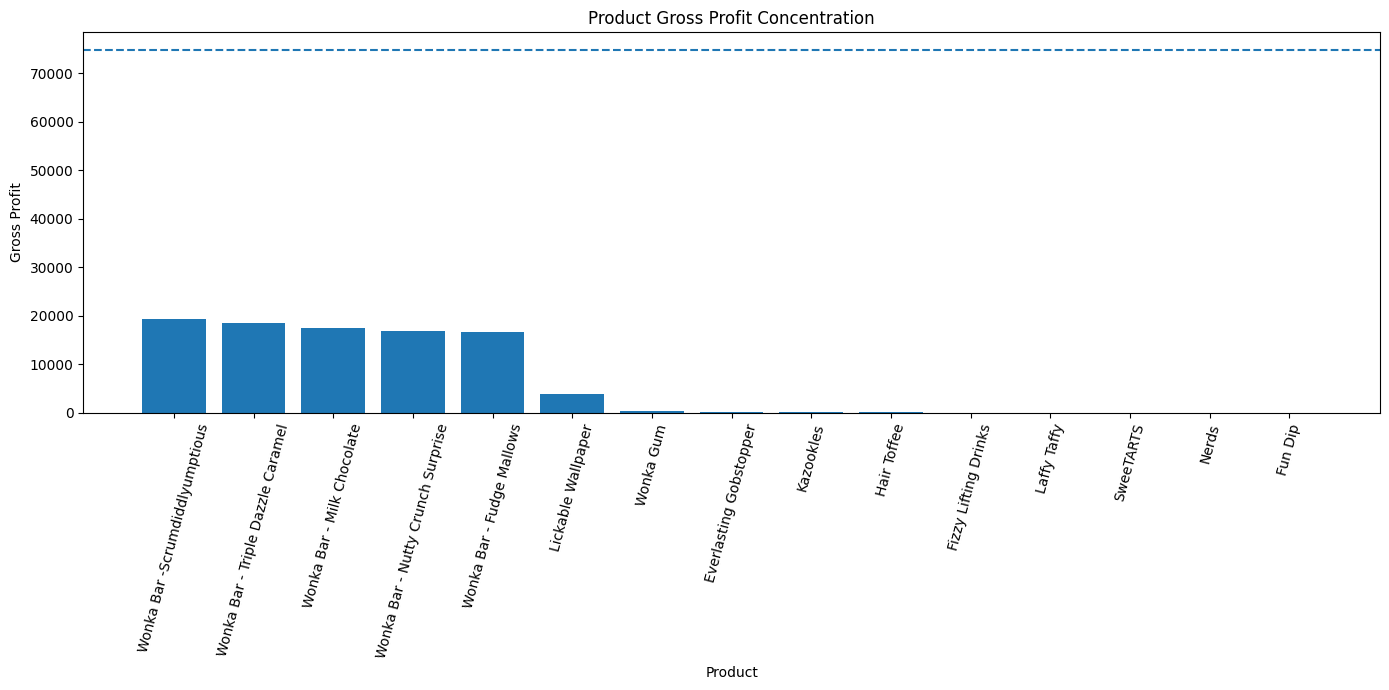

In [110]:
plt.figure(figsize=(14,7))

plt.bar(
    pareto_profit["Product Name"],
    pareto_profit["Gross_Profit"]
)

plt.axhline(
    y=pareto_profit["Gross_Profit"].sum() * 0.80,
    linestyle="--"
)

plt.title("Product Gross Profit Concentration")
plt.xlabel("Product")
plt.ylabel("Gross Profit")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [111]:
# Cost Structure Diagnostics

#This analysis examines the relationship between Cost and Sales and identifies products with relatively high cost and low profit margin.

In [112]:
# COST STRUCTURE DIAGNOSTICS

cost_analysis = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

# Calculate Profit Margin %
cost_analysis["Profit Margin %"] = (
    cost_analysis["Gross_Profit"] /
    cost_analysis["Sales"] * 100
)

cost_analysis["Profit Margin %"] = (
    cost_analysis["Profit Margin %"].round(2)
)

cost_analysis

,Product Name,Sales,Cost,Gross_Profit,Units,Profit Margin %
0,Everlasting Gobstopper,130.00,26.00,104.00,13,80.00
1,Fizzy Lifting Drinks,78.75,31.50,47.25,21,60.00
2,Fun Dip,12.00,7.20,4.80,8,40.00
3,Hair Toffee,76.50,17.00,59.50,17,77.78
4,Kazookles,1205.75,1113.00,92.75,371,7.69
5,Laffy Taffy,53.73,20.25,33.48,27,62.31
6,Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00
7,Nerds,15.00,8.00,7.00,10,46.67
8,SweeTARTS,61.50,32.80,28.70,41,46.67
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,66.67


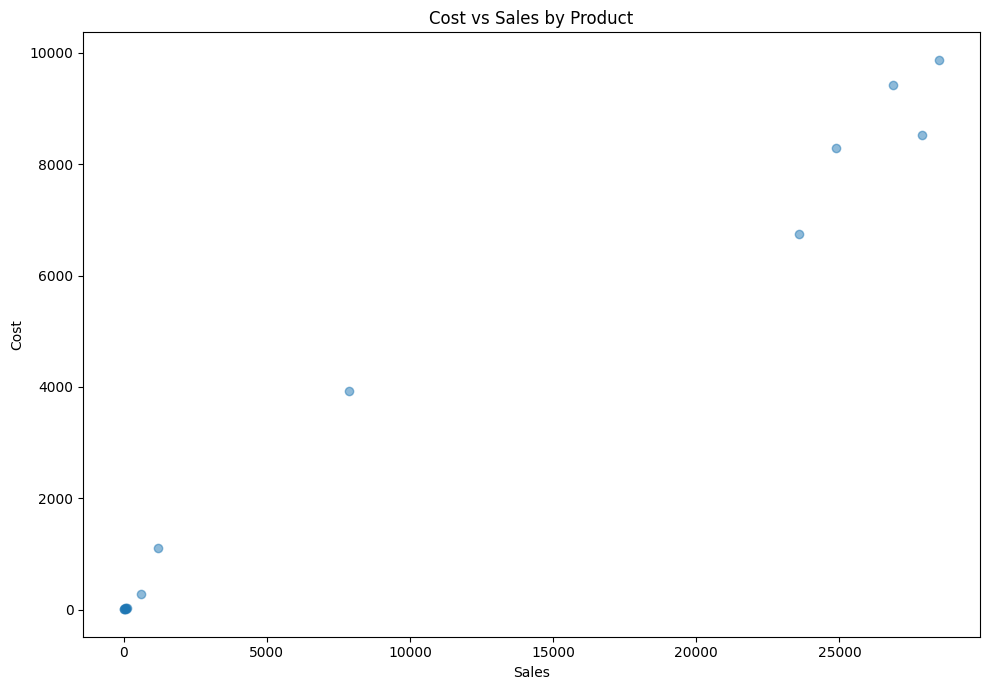

In [113]:
plt.figure(figsize=(10, 7))

plt.scatter(
    cost_analysis["Sales"],
    cost_analysis["Cost"],
    alpha=0.5
)

plt.title("Cost vs Sales by Product")
plt.xlabel("Sales")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

In [114]:
cost_analysis["Cost-to-Sales %"] = (
    cost_analysis["Cost"] /
    cost_analysis["Sales"] * 100
)

cost_analysis["Cost-to-Sales %"] = (
    cost_analysis["Cost-to-Sales %"].round(2)
)

cost_analysis.sort_values(
    "Cost-to-Sales %",
    ascending=False
)

,Product Name,Sales,Cost,Gross_Profit,Units,Profit Margin %,Cost-to-Sales %
4,Kazookles,1205.75,1113.00,92.75,371,7.69,92.31
2,Fun Dip,12.00,7.20,4.80,8,40.00,60.00
7,Nerds,15.00,8.00,7.00,10,46.67,53.33
8,SweeTARTS,61.50,32.80,28.70,41,46.67,53.33
6,Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00,50.00
14,Wonka Gum,597.50,286.80,310.70,478,52.00,48.00
1,Fizzy Lifting Drinks,78.75,31.50,47.25,21,60.00,40.00
5,Laffy Taffy,53.73,20.25,33.48,27,62.31,37.69
10,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,64.92,35.08
12,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,65.33,34.67


In [115]:
# Products with relatively high cost and low margin

margin_risk = cost_analysis[
    (cost_analysis["Cost-to-Sales %"] > 50) &
    (cost_analysis["Profit Margin %"] < 50)
].copy()

margin_risk = margin_risk.sort_values(
    "Profit Margin %",
    ascending=True
)

print("Margin Risk Products:")
display(margin_risk)

Margin Risk Products:


,Product Name,Sales,Cost,Gross_Profit,Units,Profit Margin %,Cost-to-Sales %
4,Kazookles,1205.75,1113.0,92.75,371,7.69,92.31
2,Fun Dip,12.00,7.2,4.80,8,40.00,60.00
7,Nerds,15.00,8.0,7.00,10,46.67,53.33
8,SweeTARTS,61.50,32.8,28.70,41,46.67,53.33


In [116]:
cost_heavy = cost_analysis.sort_values(
    "Cost-to-Sales %",
    ascending=False
).head(5)

print("Top 5 Cost-Heavy Products:")
display(cost_heavy)

Top 5 Cost-Heavy Products:


,Product Name,Sales,Cost,Gross_Profit,Units,Profit Margin %,Cost-to-Sales %
4,Kazookles,1205.75,1113.0,92.75,371,7.69,92.31
2,Fun Dip,12.00,7.2,4.80,8,40.00,60.00
7,Nerds,15.00,8.0,7.00,10,46.67,53.33
8,SweeTARTS,61.50,32.8,28.70,41,46.67,53.33
6,Lickable Wallpaper,7860.00,3930.0,3930.00,393,50.00,50.00


In [117]:
def assign_action(row):
    if row["Profit Margin %"] < 30 and row["Cost-to-Sales %"] > 70:
        return "Discontinuation / Major Cost Review"

    elif row["Profit Margin %"] < 40 and row["Cost-to-Sales %"] > 60:
        return "Repricing / Cost Renegotiation"

    elif row["Profit Margin %"] < 50:
        return "Margin Monitoring"

    else:
        return "Healthy"

cost_analysis["Action"] = cost_analysis.apply(
    assign_action,
    axis=1
)

cost_analysis[
    [
        "Product Name",
        "Sales",
        "Cost",
        "Gross_Profit",
        "Profit Margin %",
        "Cost-to-Sales %",
        "Action"
    ]
].sort_values(
    "Profit Margin %"
)

,Product Name,Sales,Cost,Gross_Profit,Profit Margin %,Cost-to-Sales %,Action
4,Kazookles,1205.75,1113.00,92.75,7.69,92.31,Discontinuation / Major Cost Review
2,Fun Dip,12.00,7.20,4.80,40.00,60.00,Margin Monitoring
7,Nerds,15.00,8.00,7.00,46.67,53.33,Margin Monitoring
8,SweeTARTS,61.50,32.80,28.70,46.67,53.33,Margin Monitoring
6,Lickable Wallpaper,7860.00,3930.00,3930.00,50.00,50.00,Healthy
14,Wonka Gum,597.50,286.80,310.70,52.00,48.00,Healthy
1,Fizzy Lifting Drinks,78.75,31.50,47.25,60.00,40.00,Healthy
5,Laffy Taffy,53.73,20.25,33.48,62.31,37.69,Healthy
10,Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,64.92,35.08,Healthy
12,Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,65.33,34.67,Healthy


In [118]:
print(" COST STRUCTURE DIAGNOSTICS SUMMARY")

print("\nCost-Heavy Products:")
display(
    cost_heavy[
        [
            "Product Name",
            "Cost",
            "Sales",
            "Cost-to-Sales %",
            "Profit Margin %"
        ]
    ]
)

print("\nMargin Risk Products:")
display(
    margin_risk[
        [
            "Product Name",
            "Sales",
            "Cost",
            "Profit Margin %",
            "Cost-to-Sales %"
        ]
    ]
)

print("\nRecommended Actions:")
print("• Review pricing for low-margin products.")
print("• Investigate products with high Cost-to-Sales ratios.")
print("• Consider cost renegotiation for cost-heavy products.")
print("• Review consistently low-margin products for portfolio rationalization.")

 COST STRUCTURE DIAGNOSTICS SUMMARY

Cost-Heavy Products:


,Product Name,Cost,Sales,Cost-to-Sales %,Profit Margin %
4,Kazookles,1113.0,1205.75,92.31,7.69
2,Fun Dip,7.2,12.00,60.00,40.00
7,Nerds,8.0,15.00,53.33,46.67
8,SweeTARTS,32.8,61.50,53.33,46.67
6,Lickable Wallpaper,3930.0,7860.00,50.00,50.00



Margin Risk Products:


,Product Name,Sales,Cost,Profit Margin %,Cost-to-Sales %
4,Kazookles,1205.75,1113.0,7.69,92.31
2,Fun Dip,12.00,7.2,40.00,60.00
7,Nerds,15.00,8.0,46.67,53.33
8,SweeTARTS,61.50,32.8,46.67,53.33



Recommended Actions:
• Review pricing for low-margin products.
• Investigate products with high Cost-to-Sales ratios.
• Consider cost renegotiation for cost-heavy products.
• Review consistently low-margin products for portfolio rationalization.


In [119]:
# EXECUTIVE PROFITABILITY DASHBOARD
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# KPI CALCULATIONS

total_sales = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Gross Profit"].sum()

overall_margin = (total_profit / total_sales) * 100

#PRODUCT ANALYSIS
product_dashboard = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

product_dashboard["Gross Margin %"] = (
    product_dashboard["Gross_Profit"]
    / product_dashboard["Sales"] * 100
)

product_dashboard = product_dashboard.sort_values(
    "Gross_Profit",
    ascending=False
)

# Best product by gross profit
best_product = product_dashboard.iloc[0]["Product Name"]

#DIVISION ANALYSIS
division_dashboard = (
    df.groupby("Division")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum")
      )
      .reset_index()
)

division_dashboard["Profit Margin %"] = (
    division_dashboard["Gross_Profit"]
    / division_dashboard["Sales"] * 100
)

best_division = division_dashboard.loc[
    division_dashboard["Gross_Profit"].idxmax(),
    "Division"
]

#REGION ANALYSIS

region_dashboard = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Gross_Profit=("Gross Profit", "sum")
      )
      .reset_index()
)

region_dashboard["Profit Margin %"] = (
    region_dashboard["Gross_Profit"]
    / region_dashboard["Sales"] * 100
)

best_region = region_dashboard.loc[
    region_dashboard["Gross_Profit"].idxmax(),
    "Region"
]

# MONTHLY TREND

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_dashboard = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum")
      )
      .reset_index()
)

monthly_dashboard["Order Date"] = (
    monthly_dashboard["Order Date"].dt.to_timestamp()
)


# DISPLAY KPI DASHBOARD
print ("NASSAU CANDY DISTRIBUTOR")
print("EXECUTIVE PROFITABILITY DASHBOARD")


print(f"\nTotal Sales       : ${total_sales:,.2f}")
print(f"Total Cost        : ${total_cost:,.2f}")
print(f"Gross Profit      : ${total_profit:,.2f}")
print(f"Profit Margin     : {overall_margin:.2f}%")

print(f"\nBest Product      : {best_product}")
print(f"Best Division     : {best_division}")
print(f"Best Region       : {best_region}")



NASSAU CANDY DISTRIBUTOR
EXECUTIVE PROFITABILITY DASHBOARD

Total Sales       : $141,783.63
Total Cost        : $48,340.83
Gross Profit      : $93,442.80
Profit Margin     : 65.91%

Best Product      : Wonka Bar -Scrumdiddlyumptious
Best Division     : Chocolate
Best Region       : Pacific


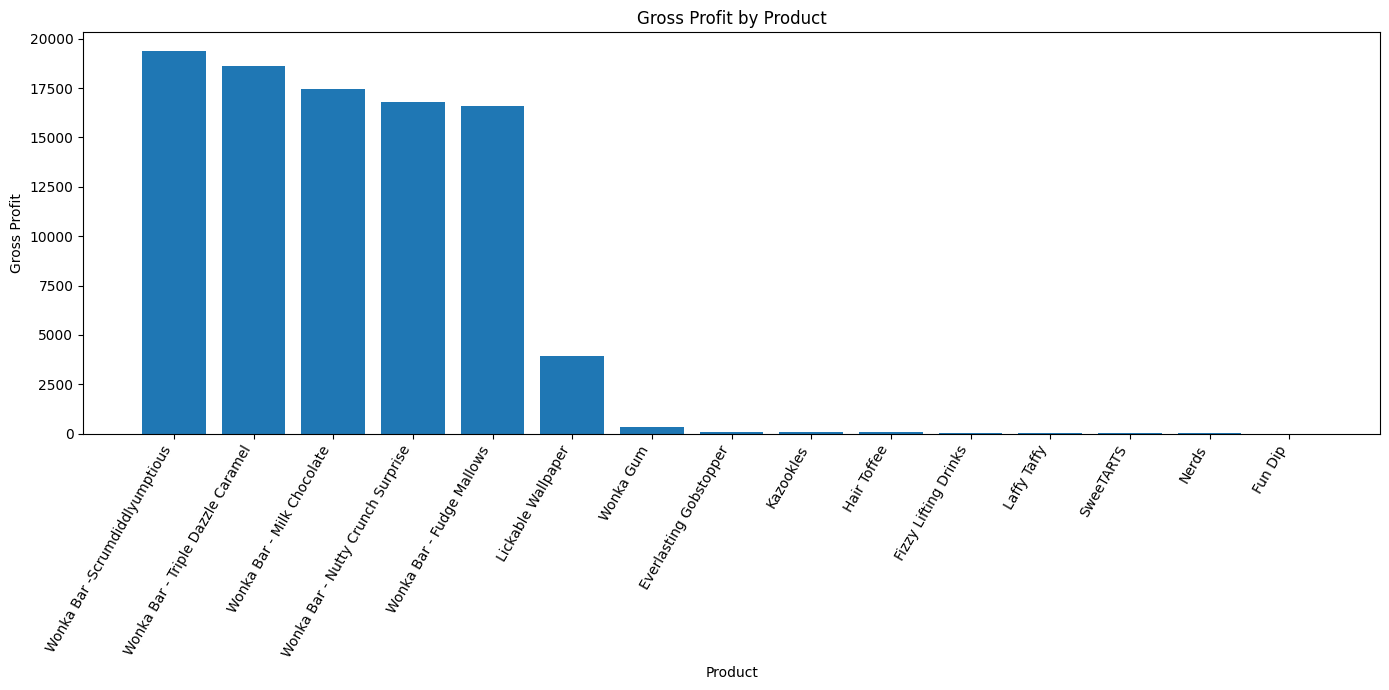

In [120]:
# PRODUCT-WISE GROSS PROFIT

plt.figure(figsize=(14, 7))

plt.bar(
    product_dashboard["Product Name"],
    product_dashboard["Gross_Profit"]
)

plt.title("Gross Profit by Product")
plt.xlabel("Product")
plt.ylabel("Gross Profit")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

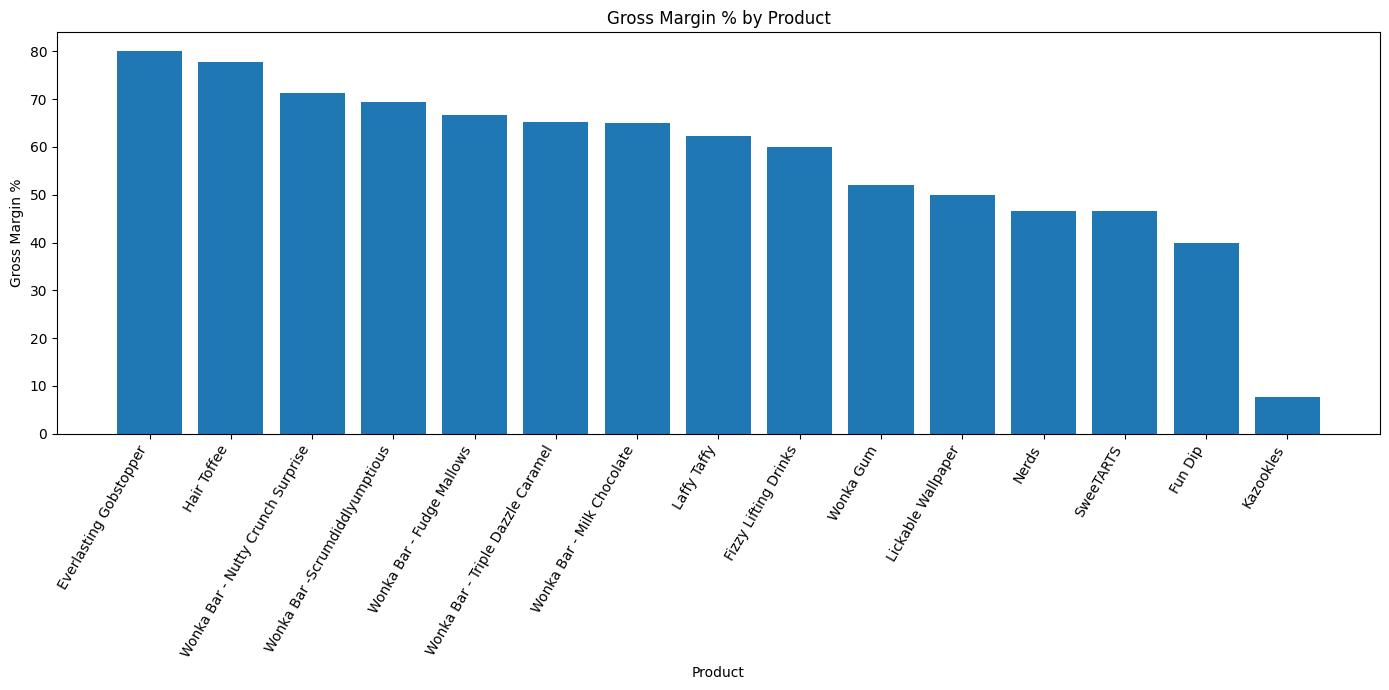

In [121]:
# PRODUCT-WISE PROFIT MARGIN

margin_dashboard = product_dashboard.sort_values(
    "Gross Margin %",
    ascending=False
)

plt.figure(figsize=(14, 7))

plt.bar(
    margin_dashboard["Product Name"],
    margin_dashboard["Gross Margin %"]
)

plt.title("Gross Margin % by Product")
plt.xlabel("Product")
plt.ylabel("Gross Margin %")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

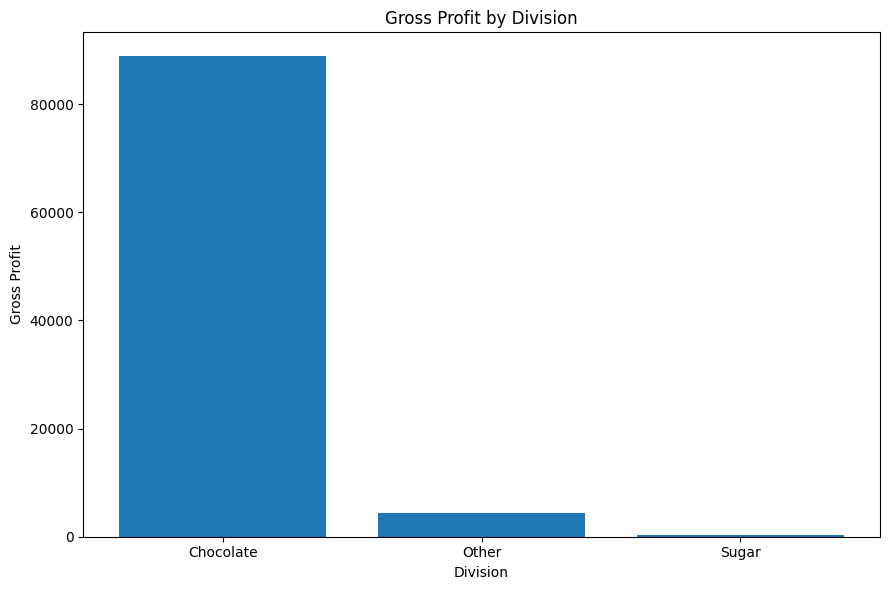

In [122]:
# DIVISION PERFORMANCE

plt.figure(figsize=(9, 6))

plt.bar(
    division_dashboard["Division"],
    division_dashboard["Gross_Profit"]
)

plt.title("Gross Profit by Division")
plt.xlabel("Division")
plt.ylabel("Gross Profit")

plt.tight_layout()
plt.show()

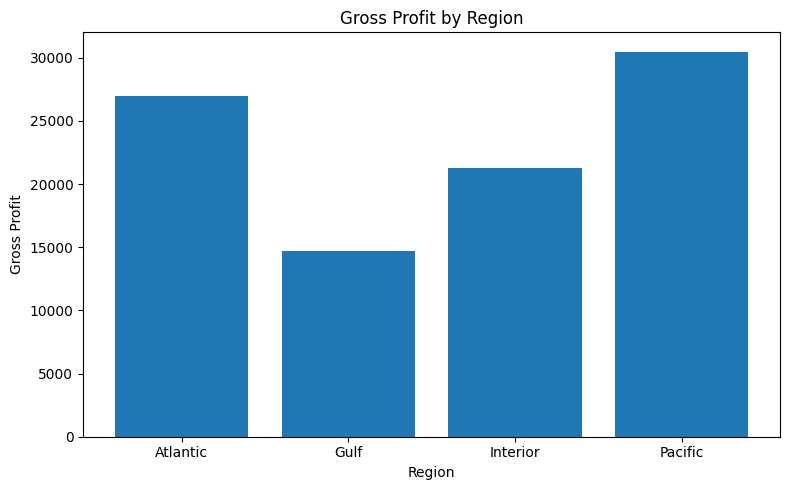

In [123]:
# REGION PERFORMANCE

plt.figure(figsize=(8, 5))

plt.bar(
    region_dashboard["Region"],
    region_dashboard["Gross_Profit"]
)

plt.title("Gross Profit by Region")
plt.xlabel("Region")
plt.ylabel("Gross Profit")

plt.tight_layout()
plt.show()

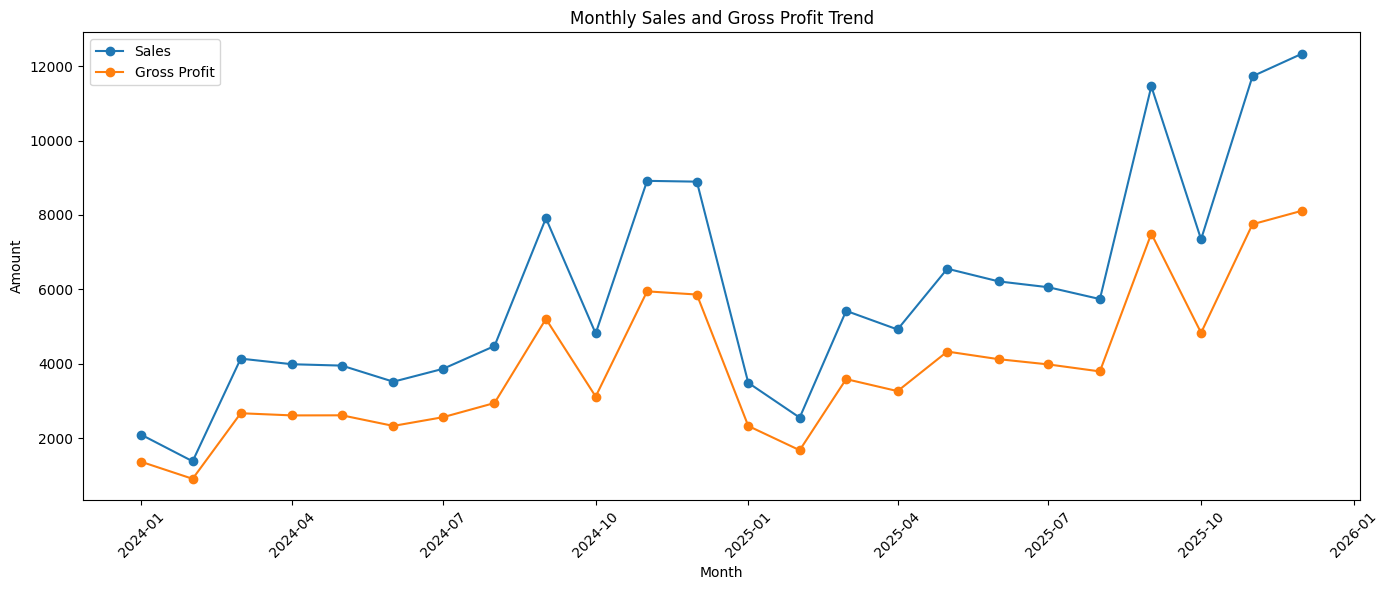

In [124]:
# MONTHLY SALES AND PROFIT TREND

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_dashboard["Order Date"],
    monthly_dashboard["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_dashboard["Order Date"],
    monthly_dashboard["Gross_Profit"],
    marker="o",
    label="Gross Profit"
)

plt.title("Monthly Sales and Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [125]:
# EXECUTIVE SUMMARY TABLE

executive_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Cost",
        "Gross Profit",
        "Profit Margin %",
        "Best Product",
        "Best Division",
        "Best Region"
    ],

    "Value": [
        f"${total_sales:,.2f}",
        f"${total_cost:,.2f}",
        f"${total_profit:,.2f}",
        f"{overall_margin:.2f}%",
        best_product,
        best_division,
        best_region
    ]
})

display(executive_summary)

,KPI,Value
0,Total Sales,"$141,783.63"
1,Total Cost,"$48,340.83"
2,Gross Profit,"$93,442.80"
3,Profit Margin %,65.91%
4,Best Product,Wonka Bar -Scrumdiddlyumptious
5,Best Division,Chocolate
6,Best Region,Pacific


In [126]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Nassau Candy Profitability Dashboard",
    page_icon="🍬",
    layout="wide"
)

st.title("🍬 Nassau Candy Distributor")
st.subheader("Product Line Profitability & Margin Performance Dashboard")

st.markdown(
    "Interactive dashboard for analysing sales, cost, gross profit, "
    "profit margins, products, divisions and regions."
)

# =========================================================
# LOAD DATA
# =========================================================

@st.cache_data
def load_data():

    df = pd.read_csv("Nassau Candy Distributor.csv")

    df["Order Date"] = pd.to_datetime(
        df["Order Date"],
        errors="coerce"
    )

    df["Gross Profit"] = (
        df["Sales"] - df["Cost"]
    )

    df["Profit Margin %"] = np.where(
        df["Sales"] != 0,
        df["Gross Profit"] / df["Sales"] * 100,
        0
    )

    return df


df = load_data()

# =========================================================
# SIDEBAR FILTERS
# =========================================================

st.sidebar.header("🔎 Dashboard Filters")

# Date filter
min_date = df["Order Date"].min().date()
max_date = df["Order Date"].max().date()

date_range = st.sidebar.date_input(
    "Order Date Range",
    value=(min_date, max_date),
    min_value=min_date,
    max_value=max_date
)

# Division filter
divisions = sorted(df["Division"].dropna().unique())

selected_divisions = st.sidebar.multiselect(
    "Division",
    divisions,
    default=divisions
)

# Margin threshold
margin_threshold = st.sidebar.slider(
    "Minimum Profit Margin %",
    min_value=0,
    max_value=100,
    value=0,
    step=5
)

# Product search
product_search = st.sidebar.text_input(
    "Product Search"
)

# =========================================================
# APPLY FILTERS
# =========================================================

filtered_df = df.copy()

if len(date_range) == 2:

    start_date = pd.to_datetime(date_range[0])
    end_date = pd.to_datetime(date_range[1])

    filtered_df = filtered_df[
        (filtered_df["Order Date"] >= start_date)
        &
        (filtered_df["Order Date"] <= end_date)
    ]

if selected_divisions:

    filtered_df = filtered_df[
        filtered_df["Division"].isin(selected_divisions)
    ]

filtered_df = filtered_df[
    filtered_df["Profit Margin %"] >= margin_threshold
]

if product_search:

    filtered_df = filtered_df[
        filtered_df["Product Name"]
        .str.contains(
            product_search,
            case=False,
            na=False
        )
    ]

# =========================================================
# KPI CALCULATIONS
# =========================================================

total_sales = filtered_df["Sales"].sum()
total_cost = filtered_df["Cost"].sum()
total_profit = filtered_df["Gross Profit"].sum()

if total_sales != 0:
    overall_margin = (
        total_profit / total_sales * 100
    )
else:
    overall_margin = 0

total_units = filtered_df["Units"].sum()

# =========================================================
# KPI CARDS
# =========================================================

st.markdown("## 📊 Executive KPIs")

col1, col2, col3, col4, col5 = st.columns(5)

col1.metric(
    "Total Sales",
    f"${total_sales:,.2f}"
)

col2.metric(
    "Total Cost",
    f"${total_cost:,.2f}"
)

col3.metric(
    "Gross Profit",
    f"${total_profit:,.2f}"
)

col4.metric(
    "Profit Margin",
    f"{overall_margin:.2f}%"
)

col5.metric(
    "Total Units",
    f"{total_units:,.0f}"
)

st.divider()

# =========================================================
# PRODUCT PROFITABILITY
# =========================================================

st.header("1️⃣ Product Profitability Overview")

product_analysis = (
    filtered_df
    .groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Cost=("Cost", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Units=("Units", "sum")
    )
    .reset_index()
)

product_analysis["Gross Margin %"] = (
    product_analysis["Gross_Profit"]
    / product_analysis["Sales"] * 100
)

product_analysis["Profit per Unit"] = np.where(
    product_analysis["Units"] != 0,
    product_analysis["Gross_Profit"]
    / product_analysis["Units"],
    0
)

product_analysis = product_analysis.sort_values(
    "Gross_Profit",
    ascending=False
)

col1, col2 = st.columns(2)

with col1:

    fig_product_profit = px.bar(
        product_analysis,
        x="Product Name",
        y="Gross_Profit",
        title="Gross Profit by Product"
    )

    fig_product_profit.update_layout(
        xaxis_tickangle=-45
    )

    st.plotly_chart(
        fig_product_profit,
        use_container_width=True
    )

with col2:

    margin_data = product_analysis.sort_values(
        "Gross Margin %",
        ascending=False
    )

    fig_margin = px.bar(
        margin_data,
        x="Product Name",
        y="Gross Margin %",
        title="Gross Margin % by Product"
    )

    fig_margin.update_layout(
        xaxis_tickangle=-45
    )

    st.plotly_chart(
        fig_margin,
        use_container_width=True
    )

st.subheader("Product Margin Leaderboard")

st.dataframe(
    product_analysis[
        [
            "Product Name",
            "Sales",
            "Cost",
            "Gross_Profit",
            "Units",
            "Gross Margin %",
            "Profit per Unit"
        ]
    ].round(2),
    use_container_width=True
)

# =========================================================
# DIVISION PERFORMANCE
# =========================================================

st.header("2️⃣ Division Performance")

division_analysis = (
    filtered_df
    .groupby("Division")
    .agg(
        Sales=("Sales", "sum"),
        Cost=("Cost", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Units=("Units", "sum")
    )
    .reset_index()
)

division_analysis["Profit Margin %"] = (
    division_analysis["Gross_Profit"]
    / division_analysis["Sales"] * 100
)

col1, col2 = st.columns(2)

with col1:

    fig_division = px.bar(
        division_analysis,
        x="Division",
        y=["Sales", "Gross_Profit"],
        barmode="group",
        title="Revenue vs Gross Profit by Division"
    )

    st.plotly_chart(
        fig_division,
        use_container_width=True
    )

with col2:

    fig_division_margin = px.bar(
        division_analysis,
        x="Division",
        y="Profit Margin %",
        title="Profit Margin by Division"
    )

    st.plotly_chart(
        fig_division_margin,
        use_container_width=True
    )

st.dataframe(
    division_analysis.round(2),
    use_container_width=True
)

# =========================================================
# COST VS MARGIN DIAGNOSTICS
# =========================================================

st.header("3️⃣ Cost vs Margin Diagnostics")

cost_margin = (
    filtered_df
    .groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Cost=("Cost", "sum"),
        Gross_Profit=("Gross Profit", "sum")
    )
    .reset_index()
)

cost_margin["Profit Margin %"] = (
    cost_margin["Gross_Profit"]
    / cost_margin["Sales"] * 100
)

fig_scatter = px.scatter(
    cost_margin,
    x="Sales",
    y="Cost",
    size="Gross_Profit",
    hover_name="Product Name",
    color="Profit Margin %",
    title="Cost vs Sales by Product"
)

st.plotly_chart(
    fig_scatter,
    use_container_width=True
)

# Margin risk flags

risk_data = cost_margin.copy()

risk_data["Margin Risk"] = np.where(
    risk_data["Profit Margin %"] < 20,
    "High Risk",
    np.where(
        risk_data["Profit Margin %"] < 40,
        "Medium Risk",
        "Low Risk"
    )
)

st.subheader("⚠️ Margin Risk Flags")

st.dataframe(
    risk_data[
        [
            "Product Name",
            "Sales",
            "Cost",
            "Gross_Profit",
            "Profit Margin %",
            "Margin Risk"
        ]
    ].sort_values(
        "Profit Margin %"
    ).round(2),
    use_container_width=True
)

# =========================================================
# PROFIT CONCENTRATION / PARETO
# =========================================================

st.header("4️⃣ Profit Concentration Analysis")

pareto = product_analysis.sort_values(
    "Gross_Profit",
    ascending=False
).copy()

pareto["Cumulative Profit"] = (
    pareto["Gross_Profit"].cumsum()
)

pareto["Cumulative Profit %"] = (
    pareto["Cumulative Profit"]
    / pareto["Gross_Profit"].sum()
    * 100
)

fig_pareto = px.bar(
    pareto,
    x="Product Name",
    y="Gross_Profit",
    title="Product Profit Contribution"
)

fig_pareto.add_scatter(
    x=pareto["Product Name"],
    y=pareto["Cumulative Profit %"],
    mode="lines+markers",
    name="Cumulative Profit %",
    yaxis="y2"
)

fig_pareto.update_layout(
    yaxis2=dict(
        title="Cumulative Profit %",
        overlaying="y",
        side="right"
    ),
    xaxis_tickangle=-45
)

st.plotly_chart(
    fig_pareto,
    use_container_width=True
)

# =========================================================
# REGIONAL PERFORMANCE
# =========================================================

st.header("5️⃣ Regional Performance")

region_analysis = (
    filtered_df
    .groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Cost=("Cost", "sum"),
        Gross_Profit=("Gross Profit", "sum")
    )
    .reset_index()
)

region_analysis["Profit Margin %"] = (
    region_analysis["Gross_Profit"]
    / region_analysis["Sales"] * 100
)

fig_region = px.bar(
    region_analysis,
    x="Region",
    y="Gross_Profit",
    title="Gross Profit by Region"
)

st.plotly_chart(
    fig_region,
    use_container_width=True
)

# =========================================================
# MONTHLY TREND
# =========================================================

st.header("6️⃣ Monthly Sales & Profit Trend")

monthly = (
    filtered_df
    .set_index("Order Date")
    .resample("M")
    .agg(
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum")
    )
    .reset_index()
)

fig_monthly = px.line(
    monthly,
    x="Order Date",
    y=["Sales", "Gross_Profit"],
    markers=True,
    title="Monthly Sales and Gross Profit"
)

st.plotly_chart(
    fig_monthly,
    use_container_width=True
)

# =========================================================
# BUSINESS INSIGHTS
# =========================================================

st.header("💡 Key Business Insights")

if len(product_analysis) > 0:

    top_profit_product = product_analysis.iloc[0]

    top_margin_product = product_analysis.loc[
        product_analysis["Gross Margin %"].idxmax()
    ]

    top_region = region_analysis.loc[
        region_analysis["Gross_Profit"].idxmax()
    ]

    top_division = division_analysis.loc[
        division_analysis["Gross_Profit"].idxmax()
    ]

    st.success(
        f"""
        **Top Profit Product:** {top_profit_product['Product Name']}

        **Highest Margin Product:** {top_margin_product['Product Name']}

        **Best Region:** {top_region['Region']}

        **Best Division:** {top_division['Division']}
        """
    )

# =========================================================
# FOOTER
# =========================================================

st.divider()

st.caption(
    "Nassau Candy Distributor | Product Line Profitability & "
    "Margin Performance Analysis"
)

Writing app.py


In [127]:
%%writefile requirements.txt

streamlit
pandas
numpy
plotly

Writing requirements.txt


In [128]:
import pandas as pd
pd.read_csv("Nassau Candy Distributor.csv")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2024-143259-CHO-MIL-31000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
10190,10191,US-2024-115427-CHO-NUT-13000,30-12-2025,26-06-2030,Standard Class,115427,United States,Fairfield,California,94533,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
10191,10192,US-2024-156720-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,156720,United States,Loveland,Colorado,80538,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
10192,10193,US-2024-143259-CHO-TRI-54000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10


In [129]:
pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 116.3 MB/s eta 0:00:00


In [130]:
!streamlit run app.py



2026-10-07 05:29:05.554 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.41.114.89:8501

  Stopping...


In [131]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) ^C


In [133]:
!pip install pyngrok -q
from google.colab import userdata
from pyngrok import ngrok
token = userdata.get('NGROK_TOKEN')
ngrok.set_auth_token(token)

In [134]:
from pyngrok import ngrok
import threading
import time
import os

def run():
  os.system("streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false")

threading.Thread(target=run).start()
time.sleep(5)

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://upward-silencer-botany.ngrok-free.dev" -> "http://localhost:8501"


In [137]:
# ============================================================
# RESULTS → RECOMMENDATIONS → CONCLUSION → REFERENCES
# Nassau Candy Distributor Profitability Analysis
# ============================================================

# -----------------------------
# 1. RESULTS
# -----------------------------

print("=" * 60)
print("RESULTS")
print("=" * 60)

print("\n1. Dataset Information")
print("Total Records:", len(df))
print("Total Columns:", len(df.columns))
print("Unique Products:", df["Product Name"].nunique())

print("\n2. Date Range")
print("First Order Date:", df["Order Date"].min())
print("Last Order Date:", df["Order Date"].max())

print("\n3. Division Performance")
division_result = (
    df.groupby("Division")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

division_result["Profit Margin %"] = (
    division_result["Profit"] /
    division_result["Sales"] * 100
)

print(division_result)

print("\n4. Region Performance")
region_result = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
)

region_result["Profit Margin %"] = (
    region_result["Profit"] /
    region_result["Sales"] * 100
)

print(region_result)

print("\n5. Top 10 Products by Profit")

top_products = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Cost=("Cost", "sum"),
          Profit=("Gross Profit", "sum"),
          Units=("Units", "sum")
      )
      .reset_index()
      .sort_values("Profit", ascending=False)
      .head(10)
)

top_products["Profit Margin %"] = (
    top_products["Profit"] /
    top_products["Sales"] * 100
)

print(top_products)


# -----------------------------
# 2. OVERALL KPIs
# -----------------------------

total_sales = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Gross Profit"].sum()
total_units = df["Units"].sum()

overall_margin = (total_profit / total_sales) * 100

print("\n" + "=" * 60)
print("OVERALL BUSINESS PERFORMANCE")
print("=" * 60)

print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Cost        : ${total_cost:,.2f}")
print(f"Total Gross Profit: ${total_profit:,.2f}")
print(f"Total Units       : {total_units:,}")
print(f"Profit Margin     : {overall_margin:.2f}%")


# -----------------------------
# 3. RECOMMENDATIONS
# -----------------------------

print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)

highest_profit_product = top_products.iloc[0]["Product Name"]
highest_profit_region = region_result.loc[
    region_result["Profit"].idxmax(), "Region"
]

highest_margin_product = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Gross Profit", "sum")
      )
      .reset_index()
)

highest_margin_product["Profit Margin %"] = (
    highest_margin_product["Profit"] /
    highest_margin_product["Sales"] * 100
)

highest_margin_product = highest_margin_product.loc[
    highest_margin_product["Profit Margin %"].idxmax(),
    "Product Name"
]

print(f"1. Focus on high-profit product: {highest_profit_product}")
print(f"2. Give special attention to high-performing region: {highest_profit_region}")
print(f"3. Monitor product margins regularly.")
print(f"4. Review low-profit products for pricing and cost optimization.")
print(f"5. Use the Streamlit dashboard for continuous performance monitoring.")
print(f"6. Maintain regular data-quality checks.")


# -----------------------------
# 4. CONCLUSION
# -----------------------------

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

print("Nassau Candy Distributor profitability analysis completed successfully.")

print(f"\nTotal Sales: ${total_sales:,.2f}")
print(f"Total Gross Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")
print(f"Best Profit Product: {highest_profit_product}")
print(f"Best Profit Region: {highest_profit_region}")

print("\nThe analysis can be used to identify profitable products,")
print("evaluate regional performance, and support business decisions.")


# -----------------------------
# 5. REFERENCES
# -----------------------------

print("\n" + "=" * 60)
print("REFERENCES")
print("=" * 60)

references = [
    "1. Python Documentation",
    "2. Pandas Documentation",
    "3. NumPy Documentation",
    "4. Matplotlib Documentation",
    "5. Plotly Documentation",
    "6. Streamlit Documentation",
    "7. Google Colab",
    "8. Nassau Candy Distributor Dataset"
]

for reference in references:
    print(reference)

RESULTS

1. Dataset Information
Total Records: 10194
Total Columns: 27
Unique Products: 15

2. Date Range
First Order Date: 2024-01-02 00:00:00
Last Order Date: 2025-12-31 00:00:00

3. Division Performance
    Division      Sales      Cost    Profit  Units  Profit Margin %
0  Chocolate  131692.90  42868.28  88824.62  37275        67.448298
1      Other    9663.25   5329.80   4333.45   1242        44.844643
2      Sugar     427.48    142.75    284.73    137        66.606625

4. Region Performance
     Region     Sales      Cost    Profit  Units  Profit Margin %
0  Atlantic  41197.24  14223.54  26973.70  11159        65.474532
1      Gulf  22247.26   7546.59  14700.67   6209        66.078564
2  Interior  32037.60  10755.11  21282.49   8820        66.429726
3   Pacific  46301.53  15815.59  30485.94  12466        65.842187

5. Top 10 Products by Profit
                         Product Name     Sales     Cost    Profit  Units  \
13     Wonka Bar -Scrumdiddlyumptious  27874.80  8517.30  1935

In [138]:
# Save analysis results

top_products.to_csv(
    "Top_10_Products_Profitability.csv",
    index=False
)

region_result.to_csv(
    "Region_Profitability_Analysis.csv",
    index=False
)

division_result.to_csv(
    "Division_Profitability_Analysis.csv",
    index=False
)

print("Analysis files saved successfully!")

Analysis files saved successfully!
